# Generate Synthetic Training Data

This notebook contains the code to generate synthetic training data for the project, _i.e._, new PROTAC molecules generated from joining ligands from the curated data (via `Chem.molzip`).

The relevant functions are the following:

- Display functions: useful to visualize the generated molecules.
- Given a ligand and a PROTAC, identify the atom index of the attachment point.
- Get the functional groups at a given attachment point, as a SMARTS.
- Get the distribution of functional groups in a given dataframe of PROTACs and their ligands.
- Generate new PROTACs by joining ligands and mimic the distribution of functional groups in the original curated data.
- Compare the distribution of functional groups in the original data and the generated data.

Our plan here is to generate (at least) 1M new PROTAC molecules, which will be used to train the model in the next steps.

## Setup

In [155]:

import os
import sys
import json
from typing import List, Dict, Tuple, Union

import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.manifold import TSNE

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem.rdchem import Mol
from rdkit.ML.Cluster import Butina
from rdkit.rdBase import BlockLogs

sys.path.append(os.path.join(os.getcwd(), '..', 'protac_splitter'))

from protac_splitter.data.generation import (
    generate_protacs,
    get_functional_group_at_attachment,
    get_functional_groups_distributions,
)
from protac_splitter.chemoinformatics import (
    canonize,
    canonize_smiles,
    canonize_smarts,
    remove_dummy_atoms,
)

In [156]:
data_dir = os.path.join(os.getcwd(), '..', 'data')

# mapped_protacs = pd.read_csv(os.path.join(data_dir, 'processed', 'mapped_protacs.csv'))
# manually_mapped_protacs = pd.read_csv(os.path.join(data_dir, 'processed', 'manually_mapped_protacs.csv'))
# protac_df = pd.concat([mapped_protacs, manually_mapped_protacs], ignore_index=True)

# # Drop duplicates on 'PROTAC SMILES' column, but keep the ones with
# # '(manually_mapped=True)' in the 'Notes' column
# protac_df = protac_df.drop_duplicates(subset='PROTAC SMILES', keep='last')

protac_df = pd.read_csv(os.path.join(data_dir, 'processed', 'mapped_protacs_with_functional_groups.csv'))

len(protac_df)

5670

In [157]:
filename_df_with_functional_groups = os.path.join(data_dir, 'processed', 'mapped_protacs_with_functional_groups.csv')
df_with_functional_groups = pd.read_csv(filename_df_with_functional_groups)
len(df_with_functional_groups)

5670

## Get Fingerprints and Embeddings

In [158]:
e3_list = df_with_functional_groups['E3 Binder SMILES with direction'].unique()
wh_list = df_with_functional_groups['POI Ligand SMILES with direction'].unique()
lk_list = df_with_functional_groups['Linker SMILES with direction'].unique()

In [269]:
morgan_fp_generator = Chem.rdFingerprintGenerator.GetMorganGenerator(
    radius=16,
    fpSize=1024,
    useBondTypes=True,
    includeChirality=True,
)

# Get the Numpy fingerprints of the ligands
e3_fp_np_list = [morgan_fp_generator.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles)) for smiles in e3_list]
wh_fp_np_list = [morgan_fp_generator.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles)) for smiles in wh_list]
lk_fp_np_list = [morgan_fp_generator.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles)) for smiles in lk_list]

# Get the fingerprints of the ligands
e3_fp_list = [morgan_fp_generator.GetFingerprint(Chem.MolFromSmiles(smiles)) for smiles in e3_list]
wh_fp_list = [morgan_fp_generator.GetFingerprint(Chem.MolFromSmiles(smiles)) for smiles in wh_list]
lk_fp_list = [morgan_fp_generator.GetFingerprint(Chem.MolFromSmiles(smiles)) for smiles in lk_list]

# Get the number of unique vectors in e3_fp_np_list
print(len(np.unique(e3_fp_np_list, axis=0)), len(e3_list))
print(len(np.unique(wh_fp_np_list, axis=0)), len(wh_list))
print(len(np.unique(lk_fp_np_list, axis=0)), len(lk_list))

253 253
883 883
1815 1927


In [270]:
import dash
from dash import dcc, html, Input, Output, no_update
import plotly.express as px
import pandas as pd
import base64
from io import BytesIO
from rdkit import Chem
from rdkit.Chem import Draw


e3_embedded = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    # perplexity=50,
    n_jobs=-1,
).fit_transform(np.array(e3_fp_np_list))

wh_embedded = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    # perplexity=3,
    n_jobs=-1,
).fit_transform(np.array(wh_fp_np_list))

lk_embedded = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    # perplexity=3,
    n_jobs=-1,
).fit_transform(np.array(lk_fp_np_list))

# Convert RDKit molecules to base64-encoded images
def mol_to_base64(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    img = Draw.MolToImage(mol, size=(300, 300))
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    return f"data:image/png;base64,{img_str}"


e3_df = pd.DataFrame(e3_embedded, columns=['x', 'y'])
e3_df['smiles'] = e3_list

# Add base64 images to DataFrame
e3_df['mol_img_base64'] = [mol_to_base64(smiles) for smiles in e3_list]

wh_df = pd.DataFrame(wh_embedded, columns=['x', 'y'])
wh_df['smiles'] = wh_list

# Add base64 images to DataFrame
wh_df['mol_img_base64'] = [mol_to_base64(smiles) for smiles in wh_list]

lk_df = pd.DataFrame(lk_embedded, columns=['x', 'y'])
lk_df['smiles'] = lk_list

# Add base64 images to DataFrame
lk_df['mol_img_base64'] = [mol_to_base64(smiles) for smiles in lk_list]

## Define the Clusters

In [ ]:
from useful_rdkit_utils.split_utils import (
    taylor_butina_clustering,
    get_bemis_murcko_clusters,
    get_umap_clusters,
)

In [201]:
from rdkit.Chem.Scaffolds.MurckoScaffold import MurckoScaffoldSmiles
from sklearn.cluster import AgglomerativeClustering, KMeans

def get_scaffold(smi: Union[str, Mol]) -> str:
    """
    Generate the Bemis-Murcko scaffold for a given molecule.

    :param smi: A SMILES string or an RDKit molecule object representing the
                molecule for which to generate the scaffold.
    :return: A SMILES string representing the Bemis-Murcko scaffold of the input
             molecule. If the scaffold cannot be generated, the input SMILES
             string is returned.
    """
    scaffold = MurckoScaffoldSmiles(smi)
    if len(scaffold) == 0:
        scaffold = smi
    return scaffold


def get_umap_clusters_fp(fp_list: List[str], n_clusters: int = 7) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the umap clustering algorithm.
    From Scaffold Splits Overestimate Virtual Screening Performance
    https://arxiv.org/abs/2406.00873



    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    ac = AgglomerativeClustering(n_clusters=n_clusters)
    ac.fit_predict(np.stack(fp_list))
    return ac.labels_


def get_kmeans_clusters_fp(fp_list: List[str], n_clusters: int = 10) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the KMeans clustering algorithm.

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42, max_iter=1000)
    return km.fit_predict(np.stack(fp_list))

E3 Num clusters:   21, avg. size: 12.05, avg. size w.r.t. data size: 4.76% (x3: 14.29%)
WH Num clusters:   16, avg. size: 55.19, avg. size w.r.t. data size: 6.25% (x3: 18.75%)
LK Num clusters:   22, avg. size: 87.59, avg. size w.r.t. data size: 4.55% (x3: 13.64%)
  - E3 silhouette: -0.116
  - E3 davies_bouldin: 1.903
  - E3 calinski_harabasz: 2.467
  - E3 avg_cluster_size: 12.048
  - E3 avg_cluster_data_ratio: 0.048
  - E3 std_cluster_size: 32.975
  - E3 min_cluster_size: 1.000
  - E3 median_cluster_size: 2.000
  - E3 max_cluster_size: 154.000
  - E3 cluster_size_skewness: 3.815
  - E3 num_clusters: 21.000

  - POI silhouette: -0.217
  - POI davies_bouldin: 3.464
  - POI calinski_harabasz: 1.125
  - POI avg_cluster_size: 55.188
  - POI avg_cluster_data_ratio: 0.062
  - POI std_cluster_size: 184.117
  - POI min_cluster_size: 1.000
  - POI median_cluster_size: 5.000
  - POI max_cluster_size: 767.000
  - POI cluster_size_skewness: 3.593
  - POI num_clusters: 16.000

  - Linker silhouette:

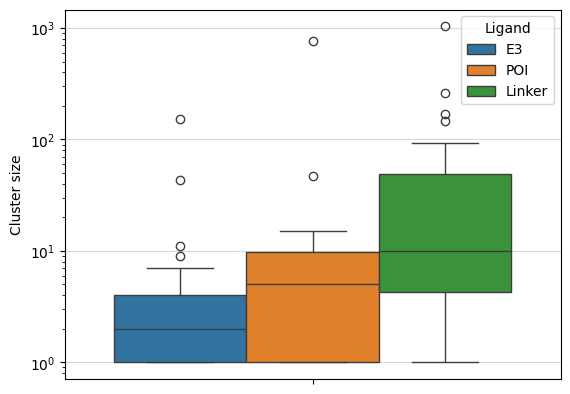

In [308]:
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import skew
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clusters(X, clusters):
    """Compute clustering metrics and assess cluster size distribution."""
    
    unique_clusters = list(set(clusters))
    
    if len(unique_clusters) < 2:  # Avoid single-cluster issues
        return {
            "silhouette": -1,
            "davies_bouldin": float("inf"),
            "calinski_harabasz": -1,
            "avg_cluster_size": len(X),
            "avg_cluster_data_ratio": 1,
            "std_cluster_size": 0,
            "min_cluster_size": len(X),
            "median_cluster_size": len(X),
            "max_cluster_size": len(X),
            "cluster_size_skewness": 0,
            "num_clusters": 1,
        }

    # Compute standard clustering metrics
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)
    calinski_harabasz = calinski_harabasz_score(X, clusters)

    # Compute cluster size statistics
    cluster_sizes = [len(np.where(clusters == i)[0]) for i in np.unique(clusters)]
    avg_cluster_size = np.mean(cluster_sizes)
    avg_cluster_data_ratio = avg_cluster_size / len(X)
    std_cluster_size = np.std(cluster_sizes)
    median_cluster_size = np.median(cluster_sizes)
    min_cluster_size = np.min(cluster_sizes)
    max_cluster_size = np.max(cluster_sizes)
    cluster_size_skewness = skew(cluster_sizes, nan_policy="omit")  # Indicates imbalance in cluster sizes

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "avg_cluster_size": avg_cluster_size,
        "avg_cluster_data_ratio": avg_cluster_data_ratio,
        "std_cluster_size": std_cluster_size,
        "min_cluster_size": min_cluster_size,
        "median_cluster_size": median_cluster_size,
        "max_cluster_size": max_cluster_size,
        "cluster_size_skewness": cluster_size_skewness,
        "num_clusters": len(unique_clusters),
    }

e3_clusters = taylor_butina_clustering(e3_fp_list, cutoff=0.86) # 0.9 might work well in practice
wh_clusters = taylor_butina_clustering(wh_fp_list, cutoff=0.90) # 0.9 might work well in practice
lk_clusters = taylor_butina_clustering(lk_fp_list, cutoff=0.87) # 0.9 might work well in practice

# e3_clusters = get_umap_clusters_fp(e3_fp_np_list, n_clusters=34) # By looking at the metrics, good value: 34
# wh_clusters = get_umap_clusters_fp(wh_fp_np_list, n_clusters=29) # By looking at the metrics, good value: 29
# lk_clusters = get_umap_clusters_fp(lk_fp_np_list, n_clusters=29) # By looking at the metrics, good value: 29

# e3_clusters = get_kmeans_clusters_fp(e3_fp_np_list, n_clusters=8) # By looking at the metrics, good value: 8
# wh_clusters = get_kmeans_clusters_fp(wh_fp_np_list, n_clusters=15) # By looking at the metrics, good value: 15
# lk_clusters = get_kmeans_clusters_fp(lk_fp_np_list, n_clusters=15) # By looking at the metrics, good value: 15

# e3_clusters = get_bemis_murcko_clusters(e3_list)
# wh_clusters = get_bemis_murcko_clusters(wh_list)
# lk_clusters = get_bemis_murcko_clusters(lk_list)

# TODO: Is the attachment point affacting the scaffold generation?
# e3_clusters = get_bemis_murcko_clusters([Chem.MolToSmiles(remove_dummy_atoms(Chem.MolFromSmiles(s))) for s in e3_list])
# wh_clusters = get_bemis_murcko_clusters([Chem.MolToSmiles(remove_dummy_atoms(Chem.MolFromSmiles(s))) for s in wh_list])
# lk_clusters = get_bemis_murcko_clusters([Chem.MolToSmiles(remove_dummy_atoms(Chem.MolFromSmiles(s))) for s in lk_list])

e3_df['cluster'] = e3_clusters
wh_df['cluster'] = wh_clusters
lk_df['cluster'] = lk_clusters

assert len(e3_list) == len(e3_clusters)
assert len(wh_list) == len(wh_clusters)
assert len(lk_list) == len(lk_clusters)

e3_avg_size = len(e3_list) / len(np.unique(e3_clusters))
wh_avg_size = len(wh_list) / len(np.unique(wh_clusters))
lk_avg_size = len(lk_list) / len(np.unique(lk_clusters))

e3_sd_size = np.std([len(np.where(e3_clusters == i)[0]) for i in np.unique(e3_clusters)])
wh_sd_size = np.std([len(np.where(wh_clusters == i)[0]) for i in np.unique(wh_clusters)])
lk_sd_size = np.std([len(np.where(lk_clusters == i)[0]) for i in np.unique(lk_clusters)])

# Print the number of unique clusters
print(f"E3 Num clusters: {len(np.unique(e3_clusters)):4d}, avg. size: {e3_avg_size:>3.2f}, avg. size w.r.t. data size: {e3_avg_size / len(e3_list):>.2%} (x3: {3 * e3_avg_size / len(e3_list):>.2%})")
print(f"WH Num clusters: {len(np.unique(wh_clusters)):4d}, avg. size: {wh_avg_size:>3.2f}, avg. size w.r.t. data size: {wh_avg_size / len(wh_list):>.2%} (x3: {3 * wh_avg_size / len(wh_list):>.2%})")
print(f"LK Num clusters: {len(np.unique(lk_clusters)):4d}, avg. size: {lk_avg_size:>3.2f}, avg. size w.r.t. data size: {lk_avg_size / len(lk_list):>.2%} (x3: {3 * lk_avg_size / len(lk_list):>.2%})")

for X, clusters, name in [(e3_fp_np_list, e3_clusters, 'E3'), (wh_fp_np_list, wh_clusters, 'POI'), (lk_fp_np_list, lk_clusters, 'Linker')]:
    metrics = evaluate_clusters(X, clusters)
    # print(f"{name} Silhouette: {metrics['silhouette']:.3f}, Davies-Bouldin: {metrics['davies_bouldin']:.3f}, Calinski-Harabasz: {metrics['calinski_harabasz']:.3f}, Avg. cluster size: {metrics['avg_cluster_size']:.2f}, Std. cluster size: {metrics['std_cluster_size']:.2f}, Min. cluster size: {metrics['min_cluster_size']}, Max. cluster size: {metrics['max_cluster_size']}, Skewness: {metrics['cluster_size_skewness']:.2f}, Num. clusters: {metrics['num_clusters']}")
    for k, v in metrics.items():
        print(f"  - {name} {k}: {v:.3f}")
    print()

# Box plot the number of elements in each cluster using seaborn
e3_sizes = [len(np.where(e3_clusters == i)[0]) for i in np.unique(e3_clusters)]
wh_sizes = [len(np.where(wh_clusters == i)[0]) for i in np.unique(wh_clusters)]
lk_sizes = [len(np.where(lk_clusters == i)[0]) for i in np.unique(lk_clusters)]

df_to_plot = pd.DataFrame({
    'Ligand': ['E3'] * len(e3_sizes) + ['POI'] * len(wh_sizes) + ['Linker'] * len(lk_sizes),
    'Cluster size': e3_sizes + wh_sizes + lk_sizes,
})

sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size')
# Set y-axis to log scale
plt.yscale('log')
plt.grid(axis='y', alpha=0.5)
plt.show()

In [306]:
# for cutoff in np.arange(0.7, 0.99, 0.005):
#     e3_clusters = taylor_butina_clustering(e3_fp_list, cutoff=cutoff)
#     wh_clusters = taylor_butina_clustering(wh_fp_list, cutoff=cutoff)
#     lk_clusters = taylor_butina_clustering(lk_fp_list, cutoff=cutoff)

#     assert len(e3_list) == len(e3_clusters)
#     assert len(wh_list) == len(wh_clusters)
#     assert len(lk_list) == len(lk_clusters)
    
#     if len(np.unique(e3_clusters)) <= 2 or len(np.unique(wh_clusters)) <= 2 or len(np.unique(lk_clusters)) <= 2:
#         break

#     e3_avg_size = len(e3_list) / len(np.unique(e3_clusters))
#     wh_avg_size = len(wh_list) / len(np.unique(wh_clusters))
#     lk_avg_size = len(lk_list) / len(np.unique(lk_clusters))
    
#     e3_avg_elem_size = e3_avg_size / len(e3_list)
#     wh_avg_elem_size = wh_avg_size / len(wh_list)
#     lk_avg_elem_size = lk_avg_size / len(lk_list)

#     if e3_avg_elem_size >= 0.05 or wh_avg_elem_size >= 0.05 or lk_avg_elem_size >= 0.05:
        
#         print(f"Cut-off: {cutoff:.3f}")
    
#         e3_sd_size = np.std([len(np.where(e3_clusters == i)[0]) for i in np.unique(e3_clusters)])
#         wh_sd_size = np.std([len(np.where(wh_clusters == i)[0]) for i in np.unique(wh_clusters)])
#         lk_sd_size = np.std([len(np.where(lk_clusters == i)[0]) for i in np.unique(lk_clusters)])

#         # Print the number of unique clusters
#         print(f"E3 Num clusters: {len(np.unique(e3_clusters)):4d}, avg. size: {e3_avg_size:>3.2f}, avg. size w.r.t. data size: {e3_avg_elem_size:>.2%} (x3: {3 * e3_avg_size / len(e3_list):>.2%})")
#         print(f"WH Num clusters: {len(np.unique(wh_clusters)):4d}, avg. size: {wh_avg_size:>3.2f}, avg. size w.r.t. data size: {wh_avg_elem_size:>.2%} (x3: {3 * wh_avg_size / len(wh_list):>.2%})")
#         print(f"LK Num clusters: {len(np.unique(lk_clusters)):4d}, avg. size: {lk_avg_size:>3.2f}, avg. size w.r.t. data size: {lk_avg_elem_size:>.2%} (x3: {3 * lk_avg_size / len(lk_list):>.2%})")

#         # Box plot the number of elements in each cluster using seaborn
#         e3_sizes = [len(np.where(e3_clusters == i)[0]) for i in np.unique(e3_clusters)]
#         wh_sizes = [len(np.where(wh_clusters == i)[0]) for i in np.unique(wh_clusters)]
#         lk_sizes = [len(np.where(lk_clusters == i)[0]) for i in np.unique(lk_clusters)]

#         df_to_plot = pd.DataFrame({
#             'Ligand': ['E3'] * len(e3_sizes) + ['POI'] * len(wh_sizes) + ['Linker'] * len(lk_sizes),
#             'Cluster size': e3_sizes + wh_sizes + lk_sizes,
#         })

#         sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size')
#         # Set y-axis to log scale
#         # plt.yscale('log')
#         plt.grid(axis='y', alpha=0.5)
#         plt.show()

In [ ]:
# Get a line plot of the matrics versus the threshold value of the taylor_butina_clustering function
def get_metrics_vs_threshold(fp_list, fp_np_list, max_threshold=1, step=0.01):
    thresholds = np.arange(0.5, max_threshold, step)
    metrics = np.array([list(evaluate_clusters(fp_np_list, taylor_butina_clustering(fp_list, cutoff=threshold)).values()) for threshold in thresholds])
    return thresholds, metrics

e3_thresholds, e3_metrics = get_metrics_vs_threshold(e3_fp_list, e3_fp_np_list)
wh_thresholds, wh_metrics = get_metrics_vs_threshold(wh_fp_list, wh_fp_np_list)
lk_thresholds, lk_metrics = get_metrics_vs_threshold(lk_fp_list, lk_fp_np_list)

Line plot threshold vs. metrics: is there a sharp change in the curve/plot at a specific threshold?

In [389]:
import plotly.graph_objects as go

layout = dict(
    hoversubplots="axis",
    title=dict(text="metrics vs. threshold"),
    hovermode="x",
    grid=dict(rows=1, columns=1),
)

data = [
    [
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 0], xaxis='x', yaxis='y', name='E3 Silhouette'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 1], xaxis='x', yaxis='y', name='E3 Davies-Bouldin'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 2], xaxis='x', yaxis='y', name='E3 Calinski-Harabasz'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 4], xaxis='x', yaxis='y', name='E3 Avg. Data Ratio'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 5] / max(e3_metrics[:, 5]), xaxis='x', yaxis='y', name='E3 STD'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 0] - e3_metrics[:, 1] + e3_metrics[:, 2] + e3_metrics[:, 4] + e3_metrics[:, 5] / max(e3_metrics[:, 5]), xaxis='x', yaxis='y', name='E3 Total'),
    ],
    [
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 0], xaxis='x', yaxis='y', name='WH Silhouette'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 1], xaxis='x', yaxis='y', name='WH Davies-Bouldin'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 2], xaxis='x', yaxis='y', name='WH Calinski-Harabasz'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 4], xaxis='x', yaxis='y', name='WH Avg. Data Ratio'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 5] / max(wh_metrics[:, 5]), xaxis='x', yaxis='y', name='WH STD'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 0] - wh_metrics[:, 1] + wh_metrics[:, 2] + wh_metrics[:, 4] + wh_metrics[:, 5] / max(wh_metrics[:, 5]), xaxis='x', yaxis='y', name='WH Total'),
    ],
    [
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 0], xaxis='x', yaxis='y', name='LK Silhouette'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 1], xaxis='x', yaxis='y', name='LK Davies-Bouldin'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 2], xaxis='x', yaxis='y', name='LK Calinski-Harabasz'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 4], xaxis='x', yaxis='y', name='LK Avg. Data Ratio'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 5] / max(lk_metrics[:, 5]), xaxis='x', yaxis='y', name='LK STD'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 0] - lk_metrics[:, 1] + lk_metrics[:, 2] + lk_metrics[:, 4] + lk_metrics[:, 5] / max(lk_metrics[:, 5]), xaxis='x', yaxis='y', name='LK Total'),
    ],
]

for d in data:
    fig = go.Figure(data=d, layout=layout)
    fig.show()

In [186]:
def get_metrics_vs_n_clusters(fp_np_list, max_clusters=20):
    n_clusters = np.arange(2, max_clusters, 1)
    metrics = np.array([list(evaluate_clusters(fp_np_list, get_kmeans_clusters_fp(fp_np_list, n_clusters=n)).values()) for n in n_clusters])
    # metrics = np.array([list(evaluate_clusters(fp_np_list, get_umap_clusters_fp(fp_np_list, n_clusters=n)).values()) for n in n_clusters])
    return n_clusters, metrics

e3_n_clusters, e3_metrics = get_metrics_vs_n_clusters(e3_fp_np_list)
wh_n_clusters, wh_metrics = get_metrics_vs_n_clusters(wh_fp_np_list)
lk_n_clusters, lk_metrics = get_metrics_vs_n_clusters(lk_fp_np_list)

In [309]:
# layout = dict(
#     hoversubplots="axis",
#     title=dict(text="E3 n_clusters vs. metrics"),
#     hovermode="x",
#     grid=dict(rows=1, columns=1),
# )

# data = [
#     go.Scatter(x=e3_n_clusters, y=e3_metrics[:, 0], xaxis='x', yaxis='y', name='E3 Silhouette'),
#     go.Scatter(x=e3_n_clusters, y=e3_metrics[:, 1], xaxis='x', yaxis='y', name='E3 Davies-Bouldin'),
#     go.Scatter(x=e3_n_clusters, y=e3_metrics[:, 2], xaxis='x', yaxis='y', name='E3 Calinski-Harabasz'),
# ]

# fig = go.Figure(data=data, layout=layout)

# fig.show()

# layout = dict(
#     hoversubplots="axis",
#     title=dict(text="WH n_clusters vs. n_metrics"),
#     hovermode="x",
#     grid=dict(rows=1, columns=1),
# )

# data = [
#     go.Scatter(x=wh_n_clusters, y=wh_metrics[:, 0], xaxis='x', yaxis='y', name='WH Silhouette'),
#     go.Scatter(x=wh_n_clusters, y=wh_metrics[:, 1], xaxis='x', yaxis='y', name='WH Davies-Bouldin'),
#     go.Scatter(x=wh_n_clusters, y=wh_metrics[:, 2], xaxis='x', yaxis='y', name='WH Calinski-Harabasz'),
# ]

# fig = go.Figure(data=data, layout=layout)

# fig.show()

# layout = dict(
#     hoversubplots="axis",
#     title=dict(text="Linker n_clusters vs. n_metrics"),
#     hovermode="x",
#     grid=dict(rows=1, columns=1),
# )

# data = [
#     go.Scatter(x=lk_n_clusters, y=wh_metrics[:, 0], xaxis='x', yaxis='y', name='LK Silhouette'),
#     go.Scatter(x=lk_n_clusters, y=wh_metrics[:, 1], xaxis='x', yaxis='y', name='LK Davies-Bouldin'),
#     go.Scatter(x=lk_n_clusters, y=wh_metrics[:, 2], xaxis='x', yaxis='y', name='LK Calinski-Harabasz'),
# ]

# fig = go.Figure(data=data, layout=layout)

# fig.show()

In [311]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score


def tanimoto_distance(A: np.ndarray, B: np.ndarray) -> float:
    """
    Compute the Tanimoto distance between two numpy arrays.

    Args:
        A (np.ndarray): First fingerprint vector.
        B (np.ndarray): Second fingerprint vector.

    Returns:
        float: Tanimoto distance (0 = identical, 1 = completely dissimilar).
    """
    dot_product = np.dot(A, B)
    norm_A = np.sum(A)
    norm_B = np.sum(B)
    
    if norm_A + norm_B - dot_product == 0:
        return 0.0  # To avoid division by zero if both are empty vectors
    
    tanimoto_sim = dot_product / (norm_A + norm_B - dot_product)
    return 1 - tanimoto_sim  # Convert similarity to distance


def plot_silhouette(X, labels, title="Silhouette Plot"):
    """
    Generate a silhouette plot for the given clustered data.

    Args:
        X (numpy.ndarray): Feature matrix (e.g., fingerprints or embeddings).
        labels (list or np.ndarray): Cluster labels for each data point.
        title (str): Title for the plot.
    """
    # Compute silhouette scores for each point
    silhouette_vals = silhouette_samples(X, labels, metric=tanimoto_distance)
    avg_score = silhouette_score(X, labels, metric=tanimoto_distance)

    # Sort silhouette values within each cluster
    unique_labels = np.unique(labels)
    y_lower = 10  # Baseline for plotting

    plt.figure(figsize=(8, 6))
    
    for i, label in enumerate(unique_labels):
        cluster_silhouette_vals = silhouette_vals[labels == label]
        cluster_silhouette_vals.sort()
        size_cluster = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster

        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7, label=f"Cluster {label}")
        
        y_lower = y_upper + 10  # Add some space between clusters

    plt.axvline(avg_score, color="red", linestyle="--", label=f"Avg silhouette: {avg_score:.2f}")

    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster Members")
    plt.title(title)
    # plt.legend()
    plt.show()

    print(f"Average Silhouette Score: {avg_score:.3f}")

# # Example usage:
# plot_silhouette(e3_fp_list, e3_clusters, title="E3 Clusters Silhouette Plot")
# plot_silhouette(wh_fp_list, wh_clusters, title="WH Clusters Silhouette Plot")
# plot_silhouette(lk_fp_list, lk_clusters, title="LK Clusters Silhouette Plot")

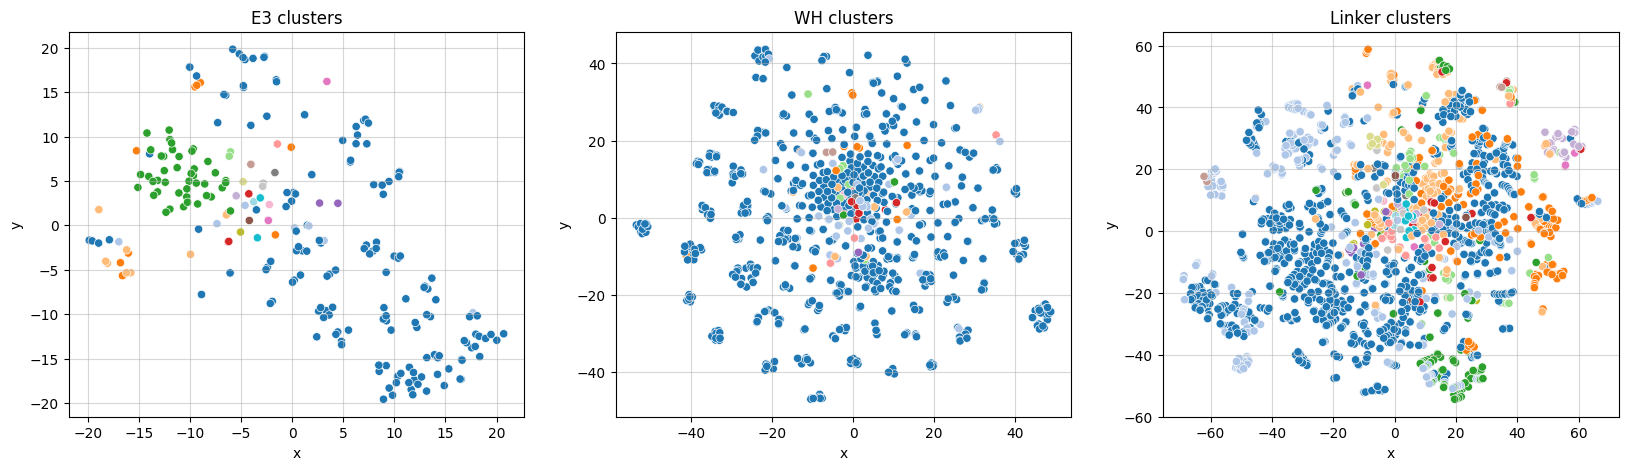

In [390]:
titles = ['E3 clusters', 'WH clusters', 'Linker clusters']

# Have the three plots in a single figure, horizontally
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for i, title in enumerate(titles):
    if title == 'E3 clusters':
        df_to_plot = e3_df.copy()
    elif title == 'WH clusters':
        df_to_plot = wh_df.copy()
    else:
        df_to_plot = lk_df.copy()

    # Use seaborn to plot the clusters
    sns.scatterplot(data=df_to_plot, x='x', y='y', hue='cluster', palette='tab20', legend=False, ax=axs[i])
    axs[i].set_title(title)
    axs[i].grid(alpha=0.5)
    
plt.show()

In [471]:
title = 'E3 clusters'
# title = 'WH clusters'
# title = 'Linker clusters'

if title == 'E3 clusters':
    df_to_plot = e3_df.copy()
elif title == 'WH clusters':
    df_to_plot = wh_df.copy()
else:
    df_to_plot = lk_df.copy()

# df_to_plot['cluster'] = e3_butina_clusters

df_to_plot['cluster'] = df_to_plot['cluster'].astype(str) # Comment out for gradient coloring

fig = px.scatter(
    df_to_plot,
    x='x',
    y='y',
    color='cluster',
    custom_data=['mol_img_base64'],  # Store base64 image data
    title=title,
)

# Disable default hover info
fig.update_traces(hoverinfo="none", hovertemplate=None)

fig.update_layout(
    width=700,  # Set the figure width (adjust as needed)
    height=700,  # Set the figure height (same as width for square shape)
    autosize=False,  # Prevent automatic resizing
    xaxis=dict(scaleanchor="y")  # Keep x and y scales equal
)

# Initialize Dash app
app = dash.Dash(__name__)

# Define layout
app.layout = html.Div([
    dcc.Graph(id="graph", figure=fig, clear_on_unhover=True),
    dcc.Tooltip(id="graph-tooltip")
])

# Callback for hover-based tooltip
@app.callback(
    Output("graph-tooltip", "show"),
    Output("graph-tooltip", "bbox"),
    Output("graph-tooltip", "children"),
    Input("graph", "hoverData")
)
def display_hover(hoverData):
    if hoverData is None:
        return False, no_update, no_update
    
    # print(hoverData)

    # Get index of hovered point
    point_index = hoverData["points"][0]["pointIndex"]

    # Get base64 image, coordinates, and cluster
    img_src = df_to_plot.iloc[point_index]['mol_img_base64']
    x_coord = df_to_plot.iloc[point_index]['x']
    y_coord = df_to_plot.iloc[point_index]['y']
    cluster = df_to_plot.iloc[point_index]['cluster']
    num_clusters = len(df_to_plot[df_to_plot['cluster'] == cluster])

    # Create tooltip content
    children = html.Div([
        # html.P(f"x: {x_coord:.2f}, y: {y_coord:.2f}", style={"margin": "5px 0", "font-size": "14px"}),
        html.P(f"Cluster: {cluster}", style={"margin": "0", "font-weight": "bold", "font-size": "14px"}),
        html.P(f"#Elems in cluster: {num_clusters}", style={"margin": "0", "font-weight": "bold", "font-size": "14px"}),
        html.Img(src=img_src, style={"width": "200px", "height": "200px"}),
    ], style={'width': '180px', 'text-align': 'center', 'white-space': 'normal'})

    # Get bounding box of hovered point
    bbox = hoverData["points"][0]["bbox"]

    return True, bbox, children

# Run app
if __name__ == "__main__":
    app.run_server(debug=True)

## Divide the Clusters in Seen/Unseen

Divide the functional groups clusters into two categories: isolate 10% of the functional groups clusters to use for the validation/test sets.

- Seen functional groups: 90% of the clusters, used for training.
- Unseen functional groups: 10% of the clusters, used for validation/test.

TODO: Do not leave out the "most common" (with most elements) cluster in the unseen category. Follow this guideline in general.

Maybe choose a medium size cluster and two small sizes for the unseen category?

E3: Avg. Cluster Size: 12.05 (4.76%)
WH: Avg. Cluster Size: 55.19 (6.25%)
LK: Avg. Cluster Size: 87.59 (4.55%)
--------------------------------------------------------------------------------
Number of E3 clusters:    5 unseen,   16 seen
Number of WH clusters:    5 unseen,   11 seen
Number of LK clusters:    5 unseen,   17 seen
--------------------------------------------------------------------------------
Number of unseen E3 ligands:   34 (13.44%)
Number of unseen WH ligands:   90 (10.19%)
Number of unseen LK ligands:  360 (18.68%)
--------------------------------------------------------------------------------


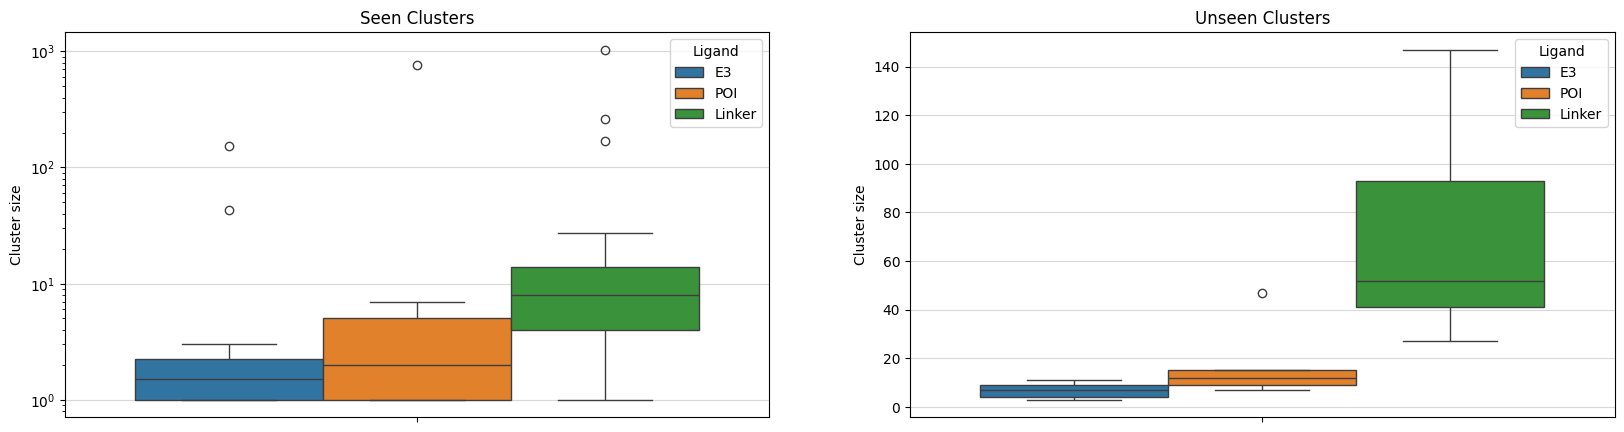

In [ ]:
from collections import defaultdict

e3_smiles2cluster = {s: c for c, s in zip(e3_clusters, e3_list)}
wh_smiles2cluster = {s: c for c, s in zip(wh_clusters, wh_list)}
lk_smiles2cluster = {s: c for c, s in zip(lk_clusters, lk_list)}

e3_cluster2smiles = defaultdict(list)
wh_cluster2smiles = defaultdict(list)
lk_cluster2smiles = defaultdict(list)

e3_cluster2size = defaultdict(lambda: 0)
wh_cluster2size = defaultdict(lambda: 0)
lk_cluster2size = defaultdict(lambda: 0)

for s, c in e3_smiles2cluster.items():
    e3_cluster2smiles[c].append(s)
    e3_cluster2size[c] += 1

for s, c in wh_smiles2cluster.items():
    wh_cluster2smiles[c].append(s)
    wh_cluster2size[c] += 1

for s, c in lk_smiles2cluster.items():
    lk_cluster2smiles[c].append(s)
    lk_cluster2size[c] += 1

# For each ligand type, get the average cluster size
e3_avg_cluster_size = np.mean(list(e3_cluster2size.values()))
wh_avg_cluster_size = np.mean(list(wh_cluster2size.values()))
lk_avg_cluster_size = np.mean(list(lk_cluster2size.values()))

print(f"E3: Avg. Cluster Size: {e3_avg_cluster_size:.2f} ({e3_avg_cluster_size / len(e3_list):.2%})")
print(f"WH: Avg. Cluster Size: {wh_avg_cluster_size:.2f} ({wh_avg_cluster_size / len(wh_list):.2%})")
print(f"LK: Avg. Cluster Size: {lk_avg_cluster_size:.2f} ({lk_avg_cluster_size / len(lk_list):.2%})")

# For each ligand type, get the cluster with the size closest to the average
e3_closest_cluster = min(e3_cluster2size, key=lambda c: abs(e3_cluster2size[c] - e3_avg_cluster_size))
wh_closest_cluster = min(wh_cluster2size, key=lambda c: abs(wh_cluster2size[c] - wh_avg_cluster_size))
lk_closest_cluster = min(lk_cluster2size, key=lambda c: abs(lk_cluster2size[c] - lk_avg_cluster_size))

# Get the top-3 closest clusters to the average size
e3_closest_clusters = sorted(e3_cluster2size, key=lambda c: abs(e3_cluster2size[c] - e3_avg_cluster_size))[:5] # [:6]
wh_closest_clusters = sorted(wh_cluster2size, key=lambda c: abs(wh_cluster2size[c] - wh_avg_cluster_size))[:5] # [:15]
lk_closest_clusters = sorted(lk_cluster2size, key=lambda c: abs(lk_cluster2size[c] - lk_avg_cluster_size))[:5] # [:5]

e3_unseen_clusters = e3_closest_clusters
wh_unseen_clusters = wh_closest_clusters
lk_unseen_clusters = lk_closest_clusters

# By "seen" we mean that the clusters are used in the training set (the rest of the clusters)
e3_seen_clusters = [c for c in set(e3_clusters) if c not in e3_unseen_clusters]
wh_seen_clusters = [c for c in set(wh_clusters) if c not in wh_unseen_clusters]
lk_seen_clusters = [c for c in set(lk_clusters) if c not in lk_unseen_clusters]

# Print their sizes
print("-" * 80)
print(f"Number of E3 clusters: {len(e3_unseen_clusters):>4d} unseen, {len(e3_seen_clusters):>4d} seen")
print(f"Number of WH clusters: {len(wh_unseen_clusters):>4d} unseen, {len(wh_seen_clusters):>4d} seen")
print(f"Number of LK clusters: {len(lk_unseen_clusters):>4d} unseen, {len(lk_seen_clusters):>4d} seen")

print("-" * 80)
e3_unseen_ligands = sum([len(e3_cluster2smiles[c]) for c in e3_unseen_clusters])
wh_unseen_ligands = sum([len(wh_cluster2smiles[c]) for c in wh_unseen_clusters])
lk_unseen_ligands = sum([len(lk_cluster2smiles[c]) for c in lk_unseen_clusters])

print(f"Number of unseen E3 ligands: {e3_unseen_ligands:>4d} ({e3_unseen_ligands / len(e3_list):.2%})")
print(f"Number of unseen WH ligands: {wh_unseen_ligands:>4d} ({wh_unseen_ligands / len(wh_list):.2%})")
print(f"Number of unseen LK ligands: {lk_unseen_ligands:>4d} ({lk_unseen_ligands / len(lk_list):.2%})")
print("-" * 80)

# Box plot the number of elements in each cluster using seaborn
e3_seen_sizes = [e3_cluster2size[c] for c in e3_seen_clusters]
wh_seen_sizes = [wh_cluster2size[c] for c in wh_seen_clusters]
lk_seen_sizes = [lk_cluster2size[c] for c in lk_seen_clusters]

e3_unseen_sizes = [e3_cluster2size[c] for c in e3_unseen_clusters]
wh_unseen_sizes = [wh_cluster2size[c] for c in wh_unseen_clusters]
lk_unseen_sizes = [lk_cluster2size[c] for c in lk_unseen_clusters]

# Have two plots in a single figure, horizontally
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

df_to_plot = pd.DataFrame({
    'Ligand': ['E3'] * len(e3_seen_sizes) + ['POI'] * len(wh_seen_sizes) + ['Linker'] * len(lk_seen_sizes),
    'Cluster size': e3_seen_sizes + wh_seen_sizes + lk_seen_sizes,
})

sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size', ax=axs[0])
axs[0].set_title("Seen Clusters")
axs[0].set_yscale('log')
axs[0].grid(axis='y', alpha=0.5)

df_to_plot = pd.DataFrame({
    'Ligand': ['E3'] * len(e3_unseen_sizes) + ['POI'] * len(wh_unseen_sizes) + ['Linker'] * len(lk_unseen_sizes),
    'Cluster size': e3_unseen_sizes + wh_unseen_sizes + lk_unseen_sizes,
})

sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size', ax=axs[1])
axs[1].set_title("Unseen Clusters")
# axs[1].set_yscale('log')
axs[1].grid(axis='y', alpha=0.5)

plt.show()

# E3 Num clusters:   21, avg. size: 12.05, avg. size w.r.t. data size: 4.76% (x3: 14.29%)
# WH Num clusters:   16, avg. size: 55.19, avg. size w.r.t. data size: 6.25% (x3: 18.75%)
# LK Num clusters:   22, avg. size: 87.59, avg. size w.r.t. data size: 4.55% (x3: 13.64%)

COC(=O)C[C@H]1[C@]2(C)C3=C(C)[C@H](c4ccoc4[*:2])C[C@H]3O[C@@H]2[C@@H]2OC(=O)[C@]3(C)C=CC(=O)[C@@]1(C)C23


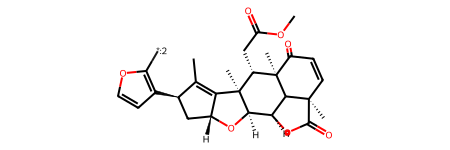

COc1ccc(C2=N[C@H](c3ccc(Cl)cc3)[C@H](c3ccc(Cl)cc3)N2C(=O)N2CCN(CC(=O)[*:2])C(=O)C2)cc1OC(C)C


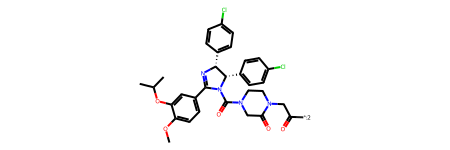

CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2cccc(OC[*:2])c2)cs1)C1CCCCC1


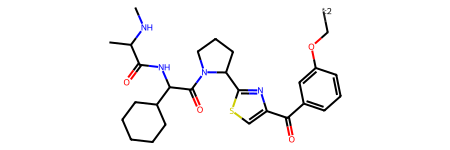

CC1(C)CCC(c2ccc(Cl)cc2)=C([*:2])C1


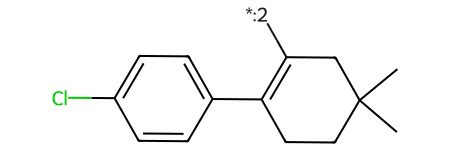

COc1ccc(C2=N[C@@H](c3ccc(Cl)cc3)[C@@H](c3ccc(Cl)cc3)N2C(=O)N2CCN(CC(=O)[*:2])C(=O)C2)cc1OC(C)C


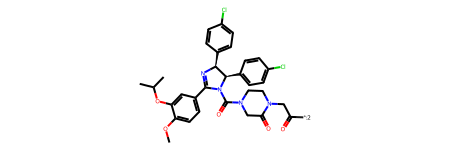

CN1CCN(c2ccc(-c3cc(C(=O)[*:2])ccc3F)cc2NC(=O)c2c[nH]c(=O)cc2C(F)(F)F)CC1


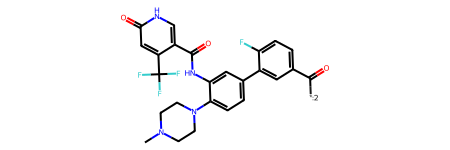

COc1ccc(C(=O)[*:2])cc1N1CCC(=O)NC1=O


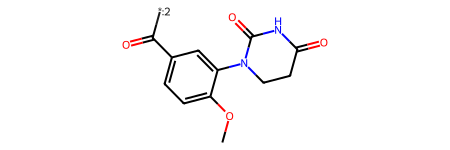

Cc1nc[nH]c1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N[*:2])C(C)(C)C)cc1


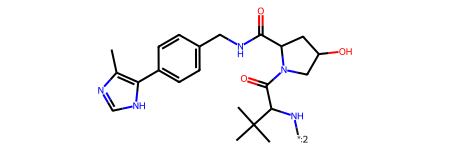

COC(=O)CC1C2(C)C3=C(C)C(c4ccoc4[*:2])CC3OC2C2OC(=O)C3(C)C=CC(=O)C1(C)C23


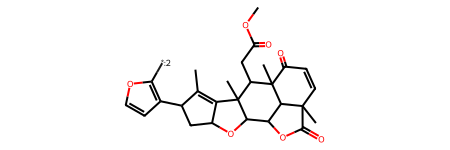

COc1ccc(C2=NC(c3ccc(Cl)cc3)C(c3ccc(Cl)cc3)N2C(=O)N2CCN(CC(=O)[*:2])C(=O)C2)cc1OC(C)C


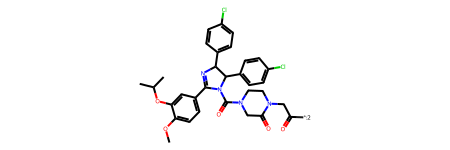

--------------------------------------------------------------------------------
O=S(=O)(c1ccc(S(=O)(=O)N(Cc2ccc(Cl)cc2)C2CCCC2)cc1)N(CC1CCCCC1)C[*:1]


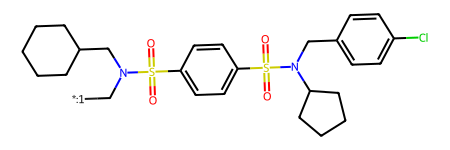

CC(C)(C)c1cc(C(=O)/C=C/c2ccc(C(=O)O)c([*:1])c2)cc(C(C)(C)C)c1


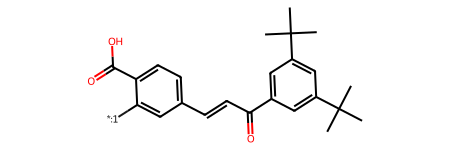

Nc1ncnc2c1c(-c1ccc(Cl)cc1)nn2[*:1]


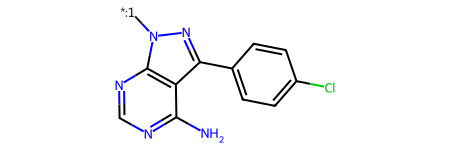

O=C1C(=CC=Cc2ccc([N+](=O)[O-])cc2)c2ccccc2N1Cc1ccc([*:1])cc1


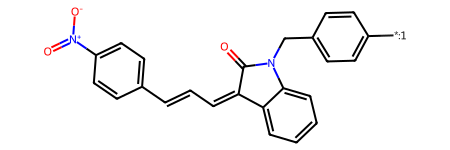

Cc1c(C#N)c(-c2ccc(C#N)cc2)c(C)n1Cc1ccccc1[*:1]


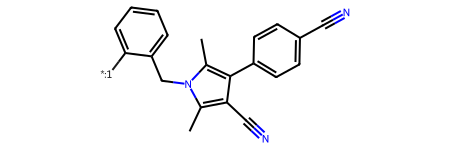

Nc1nc([*:1])nn1-c1ccc(-c2ccccc2)nn1


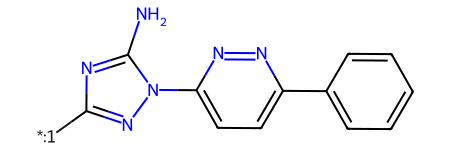

O=C1Oc2cc(O)ccc2CN1[*:1]


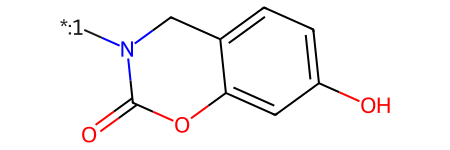

CCC(=C(c1ccccc1)c1ccc([*:1])cc1)c1ccccc1


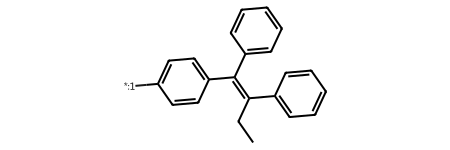

CC(C)CC(NC(=O)C(O)C(N)Cc1ccccc1)C(=O)[*:1]


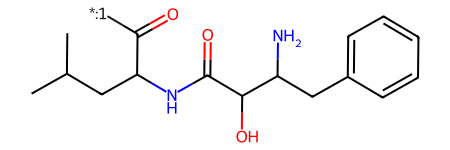

CCN(C(C(=O)NC(C)(C)C)c1ccc(Cl)cc1)[*:1]


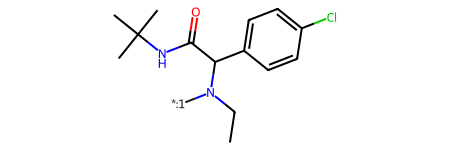

--------------------------------------------------------------------------------
C1CN([*:1])CCC1N[*:2]


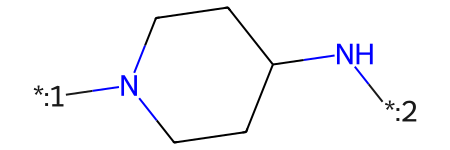

O=C(CN[*:2])NCCCC(=O)Nc1ccc(C(=O)[*:1])cc1


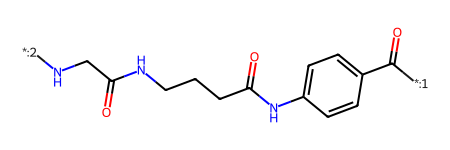

O=C(N/N=C/c1ccc(OCCCCCCCC(=O)[*:2])cc1)c1cccc([*:1])c1


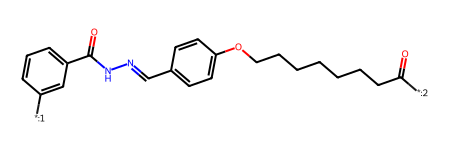

O=C(c1ccc(N2CCN(C[*:2])CC2)cc1)[*:1]


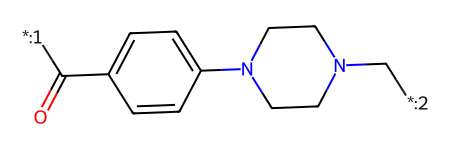

C(COCCCO[*:2])COCCC[*:1]


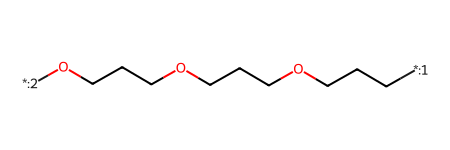

C(CCCN[*:2])CCNCCCON[*:1]


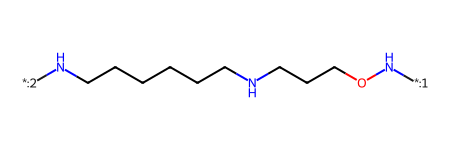

COc1cc(N=N[*:2])cc(OC)c1OCC(=O)NCCCCNC(=O)CO[*:1]


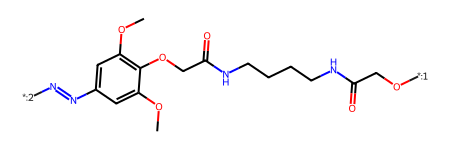

N#CCCN(c1ccc2c(c1)OCCN2CC(=O)NCCCCC[*:1])[*:2]


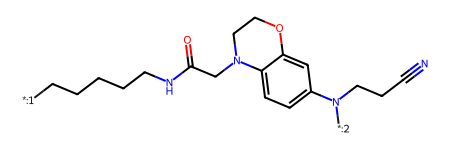

O=C(N/N=C/c1ccc(OCCCC(=O)[*:2])cc1)c1ccc([*:1])cc1


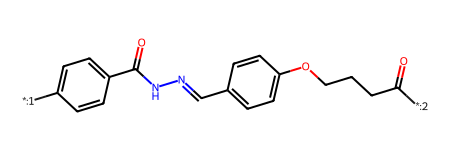

CN(CCCCN[*:2])C(C)(C)C=C(C#N)C(=O)[*:1]


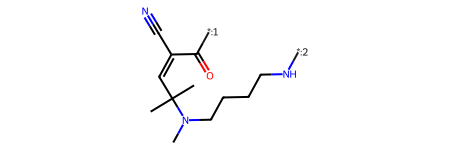

--------------------------------------------------------------------------------


In [393]:
e3_unseen_ligands = [s for c in e3_unseen_clusters for s in e3_cluster2smiles[c]]
wh_unseen_ligands = [s for c in wh_unseen_clusters for s in wh_cluster2smiles[c]]
lk_unseen_ligands = [s for c in lk_unseen_clusters for s in lk_cluster2smiles[c]]

# Sample 10 ligands from each unseen cluster and display their images
e3_unseen_ligands_sample = np.random.choice(e3_unseen_ligands, size=10, replace=False).tolist()
wh_unseen_ligands_sample = np.random.choice(wh_unseen_ligands, size=10, replace=False).tolist()
lk_unseen_ligands_sample = np.random.choice(lk_unseen_ligands, size=10, replace=False).tolist()

for e3 in e3_unseen_ligands_sample:
    print(e3)
    display(Chem.MolFromSmiles(e3))
print('-' * 80)

for wh in wh_unseen_ligands_sample:
    print(wh)
    display(Chem.MolFromSmiles(wh))
print('-' * 80)

for lk in lk_unseen_ligands_sample:
    print(lk)
    display(Chem.MolFromSmiles(lk))
print('-' * 80)

## Optuna Clustering

In [396]:
import optuna
from scipy.stats import skew
from optuna.samplers import TPESampler, GridSampler
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans

def evaluate_clusters(X, clusters):
    """Compute clustering metrics and assess cluster size distribution."""
    
    unique_clusters = list(set(clusters))
    
    if len(unique_clusters) < 2:  # Avoid single-cluster issues
        return {
            "silhouette": -1,
            "davies_bouldin": float("inf"),
            "calinski_harabasz": -1,
            "avg_cluster_size": len(X),
            "std_cluster_size": 0,
            "min_cluster_size": len(X),
            "max_cluster_size": len(X),
            "cluster_size_skewness": 0,
            "num_clusters": 1,
        }

    # Compute standard clustering metrics
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)
    calinski_harabasz = calinski_harabasz_score(X, clusters)

    # Compute cluster size statistics
    cluster_sizes = [len(np.where(clusters == i)[0]) for i in np.unique(clusters)]
    avg_cluster_size = np.mean(cluster_sizes)
    std_cluster_size = np.std(cluster_sizes)
    min_cluster_size = np.min(cluster_sizes)
    max_cluster_size = np.max(cluster_sizes)
    cluster_size_skewness = skew(cluster_sizes, nan_policy="omit")  # Indicates imbalance in cluster sizes

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "avg_cluster_size": avg_cluster_size,
        "std_cluster_size": std_cluster_size,
        "min_cluster_size": min_cluster_size,
        "max_cluster_size": max_cluster_size,
        "cluster_size_skewness": cluster_size_skewness,
        "num_clusters": len(unique_clusters),
    }


def kmeans_wrapper(trial, X):
    """Wrapper for K-Means clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (numpy.ndarray): Input feature vectors (e.g., Morgan fingerprints).
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    n_clusters = trial.suggest_int("n_clusters", 2, min(100, len(X) // 2))  # Limit to half the dataset
    init_method = trial.suggest_categorical("init", ["k-means++", "random"])
    max_iter = trial.suggest_int("max_iter", 100, 500, step=50)  # Convergence speed control
    tol = trial.suggest_float("tol", 1e-6, 1e-2, log=True)  # Precision tolerance

    try:
        model = KMeans(
            n_clusters=n_clusters,
            init=init_method,
            max_iter=max_iter,
            tol=tol,
            random_state=42
        )
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned

    return model.fit_predict(X)


def taylor_butina_wrapper(trial, X):
    """Wrapper for Taylor-Butina clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (list): List of RDKit Morgan fingerprints.
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    cutoff = trial.suggest_float("cutoff", 0.2, 0.99)  # Tanimoto similarity threshold

    try:
        clusters = taylor_butina_clustering(X, cutoff)
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned
    
    if len(np.unique(clusters)) >= len(X):
        raise optuna.exceptions.TrialPruned  # Avoid singletons
    
    return clusters


def agglomerative_wrapper(trial, X):
    """Wrapper for Agglomerative clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (numpy.ndarray): Input feature vectors (e.g., Morgan fingerprints).
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    n_clusters = trial.suggest_int("n_clusters", 2, min(100, len(X) // 2))
    linkage = trial.suggest_categorical("linkage", ["ward", "complete", "average", "single"])
    affinity = trial.suggest_categorical("affinity", ["euclidean", "l1", "l2", "manhattan", "cosine"])

    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
            metric=affinity
        )
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned

    return model.fit_predict(X)


def dbscan_wrapper(trial, X):
    """Wrapper for DBSCAN clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (numpy.ndarray): Input feature vectors (e.g., Morgan fingerprints).
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    eps = trial.suggest_float("eps", 0.1, 5.0)  # Neighborhood radius
    min_samples = trial.suggest_int("min_samples", 2, 50)  # Minimum points per cluster
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])  # Distance metric

    try:
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric=metric
        )
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned

    return model.fit_predict(X)



def evaluate_objective(metrics, X, target_cluster_size_ratio=0.1):
    """Compute a weighted objective score based on multiple clustering evaluation metrics."""
    
    if metrics is None:
        return float("-inf")
    
    if metrics["num_clusters"] < 2 or metrics["num_clusters"] >= len(X):
        return float("-inf")

    if metrics["avg_cluster_size"] < 1:
        return float("-inf")

    # Compute expected cluster size based on input percentage
    expected_size = target_cluster_size_ratio * len(X)

    # Compute penalties for deviations from expected cluster sizes
    cluster_size_penalty = abs(metrics["avg_cluster_size"] - expected_size) / expected_size
    # cluster_size_penalty = np.sqrt((metrics["avg_cluster_size"] - expected_size) ** 2)

    # Weights for balancing the optimization criteria
    alpha = 0.9  # Silhouette weight
    beta = 0.9  # Davies–Bouldin weight
    gamma = 0.9  # Calinski–Harabasz weight
    epsilon = 1.0  # Cluster size penalty (deviation from expected)
    delta = 0.1  # Cluster size std dev penalty
    zeta = 0.1  # Skewness penalty (to avoid long-tailed distributions)
    eta = 0.2  # Min/max cluster size variation penalty

    # Define a sigmoid function to squash the metrics
    sigmoid = lambda x: 1 / (1 + np.exp(-x))

    # Compute the final optimization score
    score = (
        alpha * sigmoid(metrics["silhouette"])
        - beta * sigmoid(metrics["davies_bouldin"])
        + gamma * sigmoid(metrics["calinski_harabasz"])
        - epsilon * cluster_size_penalty
        - delta * metrics["std_cluster_size"]
        - zeta * abs(metrics["cluster_size_skewness"])  # Penalize highly skewed cluster sizes
        - eta * (metrics["max_cluster_size"] - metrics["min_cluster_size"]) / expected_size  # Penalize too much spread
    )

    return score


def objective(trial, method, X, target_cluster_size_ratio=0.1):
    """Generalized Optuna objective function for clustering optimization.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter optimization.
        method (str): Clustering algorithm name (e.g., "kmeans", "agglomerative", "dbscan", "taylor_butina").
        X (numpy.ndarray or list): Input data (e.g., Morgan fingerprints).
        target_cluster_size_ratio (float, optional): Ideal average cluster size as a fraction of total data.
        
    Returns:
        float: Computed optimization score.
    """

    # Select the appropriate clustering function
    if method == "kmeans":
        clusters = kmeans_wrapper(trial, X)
    elif method == "agglomerative":
        clusters = agglomerative_wrapper(trial, X)
    elif method == "dbscan":
        clusters = dbscan_wrapper(trial, X)
    elif method == "taylor_butina":
        clusters = taylor_butina_wrapper(trial, X)
    else:
        raise ValueError(f"Unknown clustering method: {method}")
    
    if clusters is None:
        return float("-inf")

    # Compute clustering evaluation metrics
    metrics = evaluate_clusters(X, clusters)
    
    # Update the trial object with the computed metrics
    if metrics is not None:
        for key, value in metrics.items():
            trial.set_user_attr(key, value)

    trial.set_user_attr("clusters", clusters)

    # Compute the final objective score
    return evaluate_objective(metrics, X, target_cluster_size_ratio)


def optimize_clustering(X, method, n_trials=100, target_cluster_size_ratio=0.1, return_clusters: bool = False):
    """Optimize clustering hyperparameters using Optuna.
    
    Args:
        X (numpy.ndarray or list): Input data (e.g., Morgan fingerprints).
        method (str): Clustering algorithm name (e.g., "kmeans", "agglomerative", "dbscan", "taylor_butina").
        n_trials (int): Number of hyperparameter optimization trials.
        target_cluster_size_ratio (float, optional): Ideal average cluster size as a fraction of total data.
        
    Returns:
        optuna.study.Study: Optuna study object with optimization results.
    """

    # Create an Optuna study object
    if method == "taylor_butina":
        # Define a search space sampler for Taylor-Butina clustering
        lower_cutoff = 0.4
        step = (1 - lower_cutoff) / n_trials
        search_space = {"cutoff": [lower_cutoff + i * step for i in range(n_trials)]}
        sampler = GridSampler(search_space, seed=42)
    else:
        sampler = TPESampler(seed=42)  # Make the sampler behave in a deterministic way.
    study = optuna.create_study(direction="maximize", sampler=sampler)

    # Define the objective function with the specified clustering method
    objective_fn = lambda trial: objective(trial, method, X, target_cluster_size_ratio)

    # Run the optimization trials
    study.optimize(objective_fn, n_trials=n_trials)
    
    for k, v in study.best_trial.user_attrs.items():
        print(f"- {k}: {v}")

    if return_clusters:
        # Get the best hyperparameters and return the cluster labels
        best_trial = study.best_trial
        if method == "kmeans":
            clusters = kmeans_wrapper(best_trial, X)
        elif method == "agglomerative":
            clusters = agglomerative_wrapper(best_trial, X)
        elif method == "dbscan":
            clusters = dbscan_wrapper(best_trial, X)
        elif method == "taylor_butina":
            clusters = taylor_butina_wrapper(best_trial, X)
        else:
            raise ValueError(f"Unknown clustering method: {method}")

        return study, clusters

    return study


# # Optimize K-Means clustering for E3 ligands
# # e3_kmeans_clusters = optimize_clustering(e3_fp_np_list, "kmeans", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# # e3_agglo_clusters = optimize_clustering(e3_fp_np_list, "agglomerative", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# # e3_dbscan_clusters = optimize_clustering(e3_fp_np_list, "dbscan", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# e3_study, e3_butina_clusters = optimize_clustering(e3_fp_list, "taylor_butina", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# wh_study, wh_butina_clusters = optimize_clustering(wh_fp_list, "taylor_butina", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# lk_study, lk_butina_clusters = optimize_clustering(lk_fp_list, "taylor_butina", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)

# # Box plot the number of elements in each cluster using seaborn
# e3_sizes = [len(np.where(e3_butina_clusters == i)[0]) for i in np.unique(e3_butina_clusters)]
# wh_sizes = [len(np.where(wh_butina_clusters == i)[0]) for i in np.unique(wh_butina_clusters)]
# lk_sizes = [len(np.where(lk_butina_clusters == i)[0]) for i in np.unique(lk_butina_clusters)]

# df_to_plot = pd.DataFrame({
#     'Ligand': ['E3'] * len(e3_sizes) + ['POI'] * len(wh_sizes) + ['Linker'] * len(lk_sizes),
#     'Cluster size': e3_sizes + wh_sizes + lk_sizes,
# })

# sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size')
# # Set y-axis to log scale
# # plt.yscale('log')
# plt.grid(axis='y', alpha=0.5)
# plt.show()

# print(f"E3 best cutoff: {e3_study.best_params['cutoff']}")
# print(f"WH best cutoff: {wh_study.best_params['cutoff']}")
# print(f"LK best cutoff: {lk_study.best_params['cutoff']}")

## Datasets Generation

Load the functional groups distributions and the dictionaries mapping FG to substructure SMILES.

- `fg_dist`: for all ligands and for each ligand type (E3 and WH, not the linker), tehre is a dictrionary representing the distribution of functional groups in the curated data. In particular, for each SMARTS, there is a likelihood associated to it, all summing to 1 per dictionary.
- `fg_mappings`: for each ligand type (E3, WH, and linker), there is a dictionary mapping functional groups (as SMARTS) to a list of its corresponding substructures SMILES.

In [399]:
def print_fg_distr(fg_distr):
    for smarts, prob in fg_distr.items():
        print(f'{prob:2.2%} -> {smarts}')
    print('')

def print_fg_mappings(smarts2count):
    # Sort the SMILES by length
    smarts2count = {k: v for k, v in sorted(smarts2count.items(), key=lambda item: len(item[1]), reverse=True)}
    for smarts, smiles in smarts2count.items():
        print(f'[Num. SMILES: {len(smiles):3d}] {smarts} -> {smiles}')
    print('')

# Load from JSON file
filename_distributions = os.path.join(data_dir, 'processed', 'functional_group_distributions.json')
filename_mappings = os.path.join(data_dir, 'processed', 'functional_group_mappings.json')

with open(filename_distributions, 'r') as f:
    fg_distr = json.load(f)

with open(filename_mappings, 'r') as f:
    fg_mappings = json.load(f)

Example of composition:

In [410]:
print(list(fg_distr['fg_distr'].keys())[:5])
print(fg_distr['fg_distr']['[H]-[#7](-[#6])-[#6](-[#6])=[#8]'])
print(list(fg_mappings['poi_fg_2_substr'].keys())[:5])
print(fg_mappings['poi_fg_2_substr']['[H]-[#6](-[H])(-[#6])-[#7](-[#6])-[#6]'][:5])

['[H]-[#7](-[#6])-[#6](-[#6])=[#8]', '[H]-[#7](-[#6])-[#6](:[#6]):[#6]', '[#6]:[#6](:[#6])-[#8]-[#6]', '[#6]-[#6](=[#8])-[#7](-[#6])-[#6]', '[H]-[#6](-[H])(-[#6])-[#7](-[#6])-[#6]']
0.3541446208112875
['[#6]-[#6](=[#8])-[#7](-[#6])-[#6]', '[H]-[#6](-[H])(-[#6])-[#7](-[#6])-[#6]', '[H]-[#7](-[#6])-[#6](-[#7])=[#8]', '[#6]-[#7](-[#6])-[#6](-[#7])=[#16]', '[H]-[#6](-[H])(-[#6])-[#6](-[H])(-[H])-[#7]']
['CN(C)C(=O)c1cc2cnc(Nc3ccc(N4CCN([*:1])CC4)cn3)nc2n1C1CCCC1', 'C[C@@]1(C[*:1])CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1', 'Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCN([*:1])CC1', 'NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN([*:1])C[C@H](NC(=O)c3cc4cc(C(F)(F)P(=O)(O)O)ccc4[nH]3)C(=O)N21)C(=O)NC(c1ccccc1)c1ccccc1', 'COc1ccc(Cl)c(S(=O)(=O)Nc2ccc(-c3nc(OCC4CN([*:1])CCO4)c4cn[nH]c4n3)cc2)c1']


The validation/test data will be generated using the "unseen" functional groups and a small percentage of the "seen" functional groups.

In [413]:
e3_unseen_ligands = [s for c in e3_unseen_clusters for s in e3_cluster2smiles[c]]
wh_unseen_ligands = [s for c in wh_unseen_clusters for s in wh_cluster2smiles[c]]
lk_unseen_ligands = [s for c in lk_unseen_clusters for s in lk_cluster2smiles[c]]

e3_seen_ligands = [s for c in e3_seen_clusters for s in e3_cluster2smiles[c]]
wh_seen_ligands = [s for c in wh_seen_clusters for s in wh_cluster2smiles[c]]
lk_seen_ligands = [s for c in lk_seen_clusters for s in lk_cluster2smiles[c]]

# Check that they are not intersecting
assert len(set(e3_unseen_ligands).intersection(set(e3_seen_ligands))) == 0
assert len(set(wh_unseen_ligands).intersection(set(wh_seen_ligands))) == 0
assert len(set(lk_unseen_ligands).intersection(set(lk_seen_ligands))) == 0

The `generate_protacs` function expects a mapping from functional groups to lists of ligands SMILES, together with a distribution of functional groups, which we won't alter.

Regarding the mappings, we will remove the seen/unseen ligands from the lists of ligands, so that the generated PROTACs will have a different distribution of ligands.

Here is a sketch of the algorithm:

---

```python
# Train generation
train_data = generate_protacs(e3_fg_map_seen, wh_fg_map_seen, lk_fg_map_seen) # ~1M samples

# Val generation
e3_fg_map_unseen = remove_seen_from(e3)
e3_unseen = generate_protacs(e3_fg_map_unseen, wh_fg_map_seen, lk_fg_map_seen) # 5% of 10K

wh_fg_map_unseen = remove_seen_from(wh)
wh_unseen = generate_protacs(e3_fg_map_seen, wh_fg_map_unseen, lk_fg_map_seen) # 5% of 10K

lk_fg_map_unseen = remove_seen_from(lk)
lk_unseen = generate_protacs(e3_fg_map_seen, wh_fg_map_seen, lk_fg_map_unseen) # 5% of 10K

val_seen_data = generate_protacs(e3_fg_map_seen, wh_fg_map_seen, lk_fg_map_seen) # 75% of 10K
val_data = concat([e3_unseen, wh_unseen, lk_unseen, val_seen_data]) # ~10K samples
```

---

In [414]:
# Isolate the poi and e3 functional groups distributions
seen_e3_fg_2_substr = fg_mappings['e3_fg_2_substr'].copy()
seen_poi_fg_2_substr = fg_mappings['poi_fg_2_substr'].copy()
seen_substr_fg_2_linker = fg_mappings['substr_fg_2_linker'].copy()

# For each SMILES in the FG->List[SMILES] dictionary, keep only the ones that are in the "unseen" clusters
for fg, smiles in seen_e3_fg_2_substr.items():
    seen_e3_fg_2_substr[fg] = [s for s in smiles if s in e3_seen_ligands]

for fg, smiles in seen_poi_fg_2_substr.items():
    seen_poi_fg_2_substr[fg] = [s for s in smiles if s in wh_seen_ligands]

for fg, smiles in seen_substr_fg_2_linker.items():
    seen_substr_fg_2_linker[fg] = [s for s in smiles if s in lk_seen_ligands]

# Isolate the poi and e3 functional groups distributions
unseen_e3_fg_2_substr = fg_mappings['e3_fg_2_substr'].copy()
unseen_poi_fg_2_substr = fg_mappings['poi_fg_2_substr'].copy()
unseen_substr_fg_2_linker = fg_mappings['substr_fg_2_linker'].copy()

# For each SMILES in the FG->List[SMILES] dictionary, keep only the ones that are in the "unseen" clusters
for fg, smiles in unseen_e3_fg_2_substr.items():
    unseen_e3_fg_2_substr[fg] = [s for s in smiles if s in e3_unseen_ligands]

for fg, smiles in unseen_poi_fg_2_substr.items():
    unseen_poi_fg_2_substr[fg] = [s for s in smiles if s in wh_unseen_ligands]

for fg, smiles in unseen_substr_fg_2_linker.items():
    unseen_substr_fg_2_linker[fg] = [s for s in smiles if s in lk_unseen_ligands]

In [449]:
for k, v in seen_e3_fg_2_substr.items():
    print(f'{k}: {len(v)}')
print('-' * 80)
for k, v in unseen_e3_fg_2_substr.items():
    print(f'{k}: {len(v)}')

[H]-[#7](-[#6])-[#6](-[#6])=[#8]: 94
[H]-[#7](-[#6])-[#6](:[#6]):[#6]: 7
[#6]:[#6](:[#6])-[#8]-[#6]: 42
[#6]-[#8]-[#6](-[#7])=[#8]: 3
[H]-[#7](-[#6])-[#6](-[H])(-[H])-[#6]: 8
[#6]-[#16]-[#6](-[#6])(-[#6])-[#6]: 5
[#6]#[#6]-[#6](:[#6]):[#6]: 6
[H]-[#7](-[#6])-[#6](-[H])(-[H])-[#8]: 3
[H]-[#6](-[H])(-[#6])-[#7](-[#6])-[#6]: 8
[H]-[#7](-[#8])-[#6](:[#6]):[#6]: 1
[H]-[#6](-[H])(-[#7])-[#8]-[#6]: 1
[H]-[#6](-[H])(-[#6])-[#6](:[#6]):[#6]: 7
[#6]:[#6](:[#6])-[#7](-[#6])-[#6]: 11
[H]-[#6](-[H])(-[#6])-[#6](-[H])(-[H])-[#8]: 4
[#6]:[#6](:[#6])-[#6](:[#6]):[#8]: 0
[#6]:[#6](:[#6])-[#7]=[#7]: 3
[H]-[#6](-[H])(-[#8])-[#6](-[H])(-[H])-[#8]: 2
[H]-[#6](-[H])(-[#7])-[#6](-[#7])=[#8]: 2
[H]-[#6](-[H])(-[#8])-[#6](:[#6]):[#6]: 2
[H]-[#6](-[#6])(-[#6])-[#8]-[#6]: 2
[#6]-[#8]-[#6](-[#6])=[#8]: 2
[H]-[#6](-[H])(-[#6])-[#6](-[H])(-[H])-[#7]: 2
[#6]-[#6](=[#8])-[#7](-[#6])-[#6]: 13
[H]-[#6](-[H])(-[#6])-[#6](-[#7])=[#8]: 2
[H]-[#6](-[#6])(-[#6])-[#7](-[#6])-[#6]: 3
[H]-[#6](-[#6])(-[#6])-[#6](:[#6]):[#6]: 2

In [492]:
from protac_splitter.data.generation import generate_protacs

train_size = 5_000
test_size = 5_000
batch_size = 1000
cover_all_smiles = True

train_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=seen_poi_fg_2_substr,
    e3_fg_2_substr=seen_e3_fg_2_substr,
    substr_fg_2_linker=seen_substr_fg_2_linker,
    num_samples=train_size,
    random_state=42,
    original_df=df_with_functional_groups,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

avoid_df = pd.concat([train_df, df_with_functional_groups]).drop_duplicates(subset='PROTAC SMILES')

display(train_df)

assert set(e3_seen_ligands) - set(train_df['E3 Binder SMILES with direction'].unique()) == set()
assert set(wh_seen_ligands) - set(train_df['POI Ligand SMILES with direction'].unique()) == set()
assert set(lk_seen_ligands) - set(train_df['Linker SMILES with direction'].unique()) == set()

val_unseen_wh_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=unseen_poi_fg_2_substr, # Changed here
    e3_fg_2_substr=seen_e3_fg_2_substr,
    substr_fg_2_linker=seen_substr_fg_2_linker,
    num_samples=int(test_size * 0.05),
    random_state=42,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

val_unseen_e3_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=seen_poi_fg_2_substr,
    e3_fg_2_substr=unseen_e3_fg_2_substr, # Changed here
    substr_fg_2_linker=seen_substr_fg_2_linker,
    num_samples=int(test_size * 0.05),
    random_state=42,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

val_unseen_lk_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=seen_poi_fg_2_substr,
    e3_fg_2_substr=seen_e3_fg_2_substr,
    substr_fg_2_linker=unseen_substr_fg_2_linker, # Changed here
    num_samples=int(test_size * 0.05),
    random_state=42,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

val_seen_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=seen_poi_fg_2_substr,
    e3_fg_2_substr=seen_e3_fg_2_substr,
    substr_fg_2_linker=seen_substr_fg_2_linker,
    num_samples=int(test_size * 0.75),
    random_state=42,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

val_df = pd.concat([val_seen_df, val_unseen_wh_df, val_unseen_e3_df, val_unseen_lk_df]).drop_duplicates(subset='PROTAC SMILES')

avoid_df = pd.concat([avoid_df, val_df]).drop_duplicates(subset='PROTAC SMILES')

test_unseen_wh_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=unseen_poi_fg_2_substr, # Changed here
    e3_fg_2_substr=seen_e3_fg_2_substr,
    substr_fg_2_linker=seen_substr_fg_2_linker,
    num_samples=int(test_size * 0.05),
    random_state=1234,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

test_unseen_e3_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=seen_poi_fg_2_substr,
    e3_fg_2_substr=unseen_e3_fg_2_substr, # Changed here
    substr_fg_2_linker=seen_substr_fg_2_linker,
    num_samples=int(test_size * 0.05),
    random_state=1234,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

test_unseen_lk_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=seen_poi_fg_2_substr,
    e3_fg_2_substr=seen_e3_fg_2_substr,
    substr_fg_2_linker=unseen_substr_fg_2_linker, # Changed here
    num_samples=int(test_size * 0.05),
    random_state=1234,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

test_seen_df = generate_protacs_local(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=seen_poi_fg_2_substr,
    e3_fg_2_substr=seen_e3_fg_2_substr,
    substr_fg_2_linker=seen_substr_fg_2_linker,
    num_samples=int(test_size * 0.75),
    random_state=1234,
    original_df=avoid_df,
    max_workers=5,
    batch_size=batch_size,
    filename_generated_df=None,
    cover_all_smiles=cover_all_smiles,
)

test_df = pd.concat([test_seen_df, test_unseen_wh_df, test_unseen_e3_df, test_unseen_lk_df]).drop_duplicates(subset='PROTAC SMILES')

# Check that the generated dataframes are not intersecting
assert len(set(val_df['PROTAC SMILES']).intersection(set(test_df['PROTAC SMILES']))) == 0
assert len(set(val_df['PROTAC SMILES']).intersection(set(train_df['PROTAC SMILES']))) == 0
assert len(set(test_df['PROTAC SMILES']).intersection(set(train_df['PROTAC SMILES']))) == 0

Processing Results: 100%|██████████| 5/5 [00:12<00:00,  2.53s/it]


POI coverage:    94.578%
E3 coverage:     90.411%
Linker coverage: 78.366%


Covering Leftover Ligands: 100%|██████████| 403/403 [00:01<00:00, 274.33it/s, POI=100.00%, E3=100.00%, Linker=100.00%]


,PROTAC SMILES,POI Ligand SMILES with direction,Linker SMILES with direction,E3 Binder SMILES with direction,POI Ligand Functional Group,E3 Binder Functional Group
0,Cc1c(COc2ccc(CN3CCCCC3C(=O)C(=O)COCCOCCOCCONc3...,Cc1c(COc2ccc(CN3CCCCC3C(=O)[*:1])cc2Br)cccc1-c...,O=C(COCCOCCOCCO[*:2])[*:1],O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1,[#6]-[#6](=[#8])-[#7](-[#6])-[#6],[H]-[#7](-[#6])-[#6](-[#6])=[#8]
1,CNCc1ccc(-c2c3c4c(cc(F)cc4n2CCCCc2cn(CCOCCOCCO...,CNCc1ccc(-c2c3c4c(cc(F)cc4n2[*:1])C(=O)NCC3)cc1,c1c(CCCC[*:1])nnn1CCOCCOCCOCCOCCCN[*:2],O=C1CCC(c2ccc([*:2])cc2)C(=O)N1,[H]-[#6](-[H])(-[#6])-[#7](:[#6]):[#6],[H]-[#7](-[#6])-[#6](:[#6]):[#6]
2,O=C(CCCCCOc1ccc(C=NNC(=O)c2ccc(-c3c(-c4ccc(O)c...,O=C(c1ccc(-c2c(-c3ccc(O)cc3)sc3cc(O)ccc23)cc1)...,O=C(CCCCCOc1ccc(C=NN[*:1])cc1)NCC#C[*:2],O=C1CCC(N2Cc3c(cccc3[*:2])C2=O)C(=O)N1,[H]-[#7](-[#7])-[#6](-[#6])=[#8],[#6]#[#6]-[#6](:[#6]):[#6]
3,O=C1CCC(N2Cc3c(OCCCCCCCCCCCN(CCOc4ccc(C(=O)c5c...,O=C(c1ccc(OCCN(C[*:1])C2CCCCC2)cc1)c1c(-c2ccc(...,C(CCCCC[*:1])CCCCO[*:2],O=C1CCC(N2Cc3c(cccc3[*:2])C2=O)C(=O)N1,[H]-[#6](-[H])(-[#6])-[#6](-[H])(-[H])-[#7],[#6]:[#6](:[#6])-[#8]-[#6]
4,CN[C@@H](C)C(=O)N[C@H](C(=O)N1Cc2cc(C(=O)COCCC...,CC(O)(CS(=O)(=O)c1ccc(C(=O)[*:1])cc1)C(=O)Nc1c...,O=C(COCCCOCCCCO[*:1])[*:2],CN[C@@H](C)C(=O)N[C@H](C(=O)N1Cc2cc([*:2])ccc2...,[H]-[#7](-[#6])-[#6](-[#6])=[#8],[#6]:[#6](:[#6])-[#8]-[#6]
...,...,...,...,...,...,...
334,CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2ccc(F)cc...,CC(=CC(=O)NC1CN([*:1])CCC2CCC(C(=O)NC(CCC(N)=O...,O=C(CCCNCCC[*:1])NCCOCCOCCOCC[*:2],CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2ccc(F)cc...,None,None
335,O=C(CCCNCCCCCNC(=O)c1cc2c(o1)C(=O)c1ccccc1C2=O...,O=C(NCC[*:1])c1cc2c(o1)C(=O)c1ccccc1C2=O,O=C(CCCNCCC[*:1])NCC[*:2],O=C1CCC(c2ccc([*:2])cc2)C(=O)N1,None,None
336,CCC(C)(C)C(=O)C(=O)N1CCCCC1C(=O)OC(CCc1ccc(OC)...,CCC(C)(C)C(=O)C(=O)N1CCCCC1C(=O)OC(CCc1ccc(OC)...,FC1CN(CC2CCN([*:2])CC2)CCC1[*:1],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,None,None
337,Cc1nc(CCC(=O)OP(=O)(O)NCCOCCOCCOCCC(=O)Nc2cccc...,Cc1nc(CCC(=O)[*:1])ccc1-c1cnc(NCc2c(F)ccc3c2CC...,O=C(CCOCCOCCOCCNP(=O)(O)O[*:1])[*:2],O=C1CCC(n2nnc3cccc(N[*:2])c3c2=O)C(=O)N1,None,None


Processing Results:   0%|          | 0/1 [00:02<?, ?it/s]


...

Processing Results:   0%|          | 0/1 [00:01<?, ?it/s]


POI coverage:    49.685%
E3 coverage:     71.233%
Linker coverage: 57.222%


Processing Results: 100%|██████████| 4/4 [00:09<00:00,  2.45s/it]


POI coverage:    91.803%
E3 coverage:     85.388%
Linker coverage: 72.687%


Covering Leftover Ligands: 100%|██████████| 525/525 [00:02<00:00, 249.35it/s, POI=100.00%, E3=100.00%, Linker=100.00%]


In [493]:
# Check that the intersection of E3, WH, and LK between train and val/test is NOT empty
assert len(set(val_df['E3 Binder SMILES with direction']).intersection(set(train_df['E3 Binder SMILES with direction']))) > 0
assert len(set(test_df['E3 Binder SMILES with direction']).intersection(set(train_df['E3 Binder SMILES with direction']))) > 0
assert set(val_df['E3 Binder SMILES with direction']) - set(test_df['E3 Binder SMILES with direction']) == set()

assert len(set(val_df['POI Ligand SMILES with direction']).intersection(set(train_df['POI Ligand SMILES with direction']))) > 0
assert len(set(test_df['POI Ligand SMILES with direction']).intersection(set(train_df['POI Ligand SMILES with direction']))) > 0
assert set(val_df['POI Ligand SMILES with direction']) - set(test_df['POI Ligand SMILES with direction']) == set()

assert len(set(val_df['Linker SMILES with direction']).intersection(set(train_df['Linker SMILES with direction']))) > 0
assert len(set(test_df['Linker SMILES with direction']).intersection(set(train_df['Linker SMILES with direction']))) > 0
assert set(val_df['Linker SMILES with direction']) - set(test_df['Linker SMILES with direction']) == set()

In [494]:
print(f"Number of unseen E3 ligands: {len(e3_unseen_ligands):>4d} ({len(e3_unseen_ligands) / len(e3_list):.2%})")
print(f"Number of unseen WH ligands: {len(wh_unseen_ligands):>4d} ({len(wh_unseen_ligands) / len(wh_list):.2%})")
print(f"Number of unseen LK ligands: {len(lk_unseen_ligands):>4d} ({len(lk_unseen_ligands) / len(lk_list):.2%})")
print('-' * 80)

for ligand in ['E3 Binder SMILES with direction', 'POI Ligand SMILES with direction', 'Linker SMILES with direction']:
    print(f"Train {ligand}: {len(train_df[ligand].unique())}")
    print(f"Val {ligand}: {len(val_df[ligand].unique())}")
    print(f"Test {ligand}: {len(test_df[ligand].unique())}")
    
    print('-' * 40)
    
    if ligand == 'E3 Binder SMILES with direction':
        unseen_ligands = e3_unseen_ligands
    elif ligand == 'POI Ligand SMILES with direction':
        unseen_ligands = wh_unseen_ligands
    else:
        unseen_ligands = lk_unseen_ligands
    
    train_num_unseen = sum([1 if x in unseen_ligands else 0 for x in train_df[ligand].unique()])
    val_num_unseen = sum([1 if x in unseen_ligands else 0 for x in val_df[ligand].unique()])
    test_num_unseen = sum([1 if x in unseen_ligands else 0 for x in test_df[ligand].unique()])
    
    print(f"Train {ligand} unseen: {train_num_unseen} ({train_num_unseen / len(unseen_ligands):2.2%})")
    print(f"Val {ligand} unseen: {val_num_unseen} ({val_num_unseen / len(unseen_ligands):2.2%})")
    print(f"Test {ligand} unseen: {test_num_unseen} ({test_num_unseen / len(unseen_ligands):2.2%})")
    print('-' * 80)

Number of unseen E3 ligands:   34 (13.44%)
Number of unseen WH ligands:   90 (10.19%)
Number of unseen LK ligands:  360 (18.68%)
--------------------------------------------------------------------------------
Train E3 Binder SMILES with direction: 219
Val E3 Binder SMILES with direction: 253
Test E3 Binder SMILES with direction: 253
----------------------------------------
Train E3 Binder SMILES with direction unseen: 0 (0.00%)
Val E3 Binder SMILES with direction unseen: 34 (100.00%)
Test E3 Binder SMILES with direction unseen: 34 (100.00%)
--------------------------------------------------------------------------------
Train POI Ligand SMILES with direction: 793
Val POI Ligand SMILES with direction: 883
Test POI Ligand SMILES with direction: 883
----------------------------------------
Train POI Ligand SMILES with direction unseen: 0 (0.00%)
Val POI Ligand SMILES with direction unseen: 90 (100.00%)
Test POI Ligand SMILES with direction unseen: 90 (100.00%)
---------------------------

send statistics when done with the generation of the synthetic data.

the percentages seen/unseen refer to the ligands SMILES, not the functional groups.

TODO: When sampling the val/test data, make sure to:

- Not sample all unseen ligands, i.e., one out of E3, linker and WH need to be seen.
- Balance sampling seen and unseen ligands after after sampling the functional group. 

TODO: When covering the unseen ligands, is it ok to sample SMILES only from the "leftover" ones? Or shall I sample from all the ligands? Does it make a difference?

- Answer: it is ok to sample from the "leftover" ligands only. It shouldn't make a (significant) difference.

In [468]:
import os
from concurrent.futures import ThreadPoolExecutor
from typing import Dict, List, Optional

import pandas as pd
import numpy as np
from tqdm import tqdm
from rdkit import Chem

from protac_splitter.evaluation import check_reassembly


def generate_protacs_local(
        poi_fg_distr: Dict[str, float],
        e3_fg_distr: Dict[str, float],
        substr_fg_2_linker: Dict[str, List[str]],
        poi_fg_2_substr: Dict[str, List[str]],
        e3_fg_2_substr: Dict[str, List[str]],
        num_samples: int,
        random_state: int = 42,
        batch_size: int = 1000,
        max_workers: int = 4,
        original_df: Optional[pd.DataFrame] = None,
        filename_generated_df: Optional[str] = None,
        base_data_dir: Optional[str] = None,
        cover_all_smiles: bool = False,
) -> pd.DataFrame:
    """ Generate PROTACs given the distributions of functional groups at attachment points.
    
    Args:
        poi_fg_distr: The distribution of functional groups at the POI attachment point.
        e3_fg_distr: The distribution of functional groups at the E3 attachment point.
        substr_fg_2_linker: The mapping of functional groups to linkers.
        poi_fg_2_substr: The mapping of functional groups to POI substrates.
        e3_fg_2_substr: The mapping of functional groups to E3 substrates.
        num_samples: The number of PROTACs to generate.
        random_state: The random state for reproducibility.
        batch_size: The batch size for generating PROTACs.
        max_workers: The maximum number of workers for the ThreadPoolExecutor.
        original_df: The original DataFrame containing the PROTACs.
        filename_generated_df: The filename to save the generated PROTACs.

    Returns:
        pd.DataFrame: The DataFrame containing the generated PROTACs.
    """

    np.random.seed(random_state)
    final_df = pd.DataFrame()
    total_batches = int(np.ceil(num_samples / batch_size))

    def generate_protac_batch(batch_size: int, random_state: int) -> List[dict]:
        np.random.seed(random_state)

        # Sample functional groups for POI and E3
        poi_fgs = np.random.choice(list(poi_fg_distr.keys()), size=batch_size, p=list(poi_fg_distr.values()))
        e3_fgs = np.random.choice(list(e3_fg_distr.keys()), size=batch_size, p=list(e3_fg_distr.values()))

        # Map functional groups to corresponding substrates
        # NOTE: When size argument is specified, the output is a numpy array.
        # NOTE: If the functional group is not in the dictionary, the output is an empty numpy array.
        poi_samples = [
            np.random.choice(poi_fg_2_substr.get(fg, []), size=1 if fg in poi_fg_2_substr and poi_fg_2_substr[fg] else 0)
            for fg in poi_fgs
        ]
        e3_samples = [
            np.random.choice(e3_fg_2_substr.get(fg, []), size=1 if fg in e3_fg_2_substr and e3_fg_2_substr[fg] else 0)
            for fg in e3_fgs
        ]

        generated_protacs = []

        for poi_smiles, poi_fg, e3_smiles, e3_fg in zip(poi_samples, poi_fgs, e3_samples, e3_fgs):
            # Check if poi_smiles and e3_smiles are not an empty numpy array
            if poi_smiles.size == 0 or e3_smiles.size == 0:
                continue

            # Convert the numpy arrays to strings
            poi_smiles, e3_smiles = poi_smiles[0], e3_smiles[0]
            
            linkers = set(substr_fg_2_linker.get(poi_fg, [])) & set(substr_fg_2_linker.get(e3_fg, []))
            if not linkers:
                continue

            linker_smiles = np.random.choice(list(linkers))

            # Get the PROTAC by combining the POI, linker, and E3
            ligands_smiles = '.'.join([poi_smiles, linker_smiles, e3_smiles])
            protac = Chem.MolFromSmiles(ligands_smiles)

            if protac is None:
                continue
            try:
                protac = Chem.molzip(protac)
            except:
                continue

            # Sanitize molecule
            try:
                zero_on_success = Chem.SanitizeMol(protac, catchErrors=True)
                if zero_on_success != 0:
                    continue
                protac_smiles = Chem.MolToSmiles(protac, canonical=True)
            except:
                continue

            if original_df is not None and protac_smiles in original_df['PROTAC SMILES'].values:
                continue
            
            # Check if PROTAC can be reassembled
            if not check_reassembly(protac_smiles, ligands_smiles):
                continue

            generated_protacs.append({
                'PROTAC SMILES': protac_smiles,
                'POI Ligand SMILES with direction': poi_smiles,
                'Linker SMILES with direction': linker_smiles,
                'E3 Binder SMILES with direction': e3_smiles,
                'POI Ligand Functional Group': poi_fg,
                'E3 Binder Functional Group': e3_fg,
            })

        return generated_protacs

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        for i in tqdm(range(total_batches), desc="Generating Batches"):
            futures.append(executor.submit(generate_protac_batch, batch_size, random_state + i))

        for i, future in tqdm(enumerate(futures), desc="Processing Results", total=total_batches):
            generated_batch = future.result()
            if generated_batch:
                batch_df = pd.DataFrame(generated_batch)
                final_df = pd.concat([final_df, batch_df]).drop_duplicates()
                if i % 100 == 0:
                    if base_data_dir:
                        batch_df.to_csv(os.path.join(base_data_dir, f'generated_protacs_batch={i}.csv'), index=False)
                    else:
                        batch_df.to_csv(f'generated_protacs_batch={i}.csv', index=False)
                    if filename_generated_df:
                        final_df.to_csv(filename_generated_df, index=False)
                if len(final_df) >= num_samples:
                    break

        if not final_df.empty:
            generated_pois = set(final_df['POI Ligand SMILES with direction'].unique())
            generated_e3s = set(final_df['E3 Binder SMILES with direction'].unique())
            generated_linkers = set(final_df['Linker SMILES with direction'].unique())
        else:
            generated_pois = set()
            generated_e3s = set()
            generated_linkers = set()

        # Check how we covered the available substructures
        avail_pois = set()
        avail_e3s = set()
        avail_linkers = set()
        for fg in poi_fg_2_substr:
            avail_pois.update(set(poi_fg_2_substr[fg]))
        for fg in e3_fg_2_substr:
            avail_e3s.update(set(e3_fg_2_substr[fg]))
        for fg in substr_fg_2_linker:
            avail_linkers.update(set(substr_fg_2_linker[fg]))
            
        e3_coverage = len(generated_e3s) / len(avail_e3s)
        poi_coverage = len(generated_pois) / len(avail_pois)
        linker_coverage = len(generated_linkers) / len(avail_linkers)

        print(f"POI coverage:    {poi_coverage:.3%}")
        print(f"E3 coverage:     {e3_coverage:.3%}")
        print(f"Linker coverage: {linker_coverage:.3%}")
        
        # Get the "leftover" ligands
        leftover_pois = avail_pois - generated_pois
        leftover_e3s = avail_e3s - generated_e3s
        leftover_linkers = avail_linkers - generated_linkers
        
        covering_df = []

        with tqdm(total=len(leftover_pois) + len(leftover_e3s) + len(leftover_linkers), desc="Covering Leftover Ligands") as pbar:
            while True:
                if not cover_all_smiles:
                    break

                # Randomly select a POI, E3, and linker
                if not leftover_pois:
                    pois_to_sample = avail_pois
                else:
                    pois_to_sample = leftover_pois
                if not leftover_e3s:
                    e3s_to_sample = avail_e3s
                else:
                    e3s_to_sample = leftover_e3s
                if not leftover_linkers:
                    linkers_to_sample = avail_linkers
                else:
                    linkers_to_sample = leftover_linkers

                poi_smiles = np.random.choice(list(pois_to_sample))
                e3_smiles = np.random.choice(list(e3s_to_sample))
                linker_smiles = np.random.choice(list(linkers_to_sample))
                
                # Get the PROTAC by combining the POI, linker, and E3
                ligands_smiles = '.'.join([poi_smiles, linker_smiles, e3_smiles])
                protac = Chem.MolFromSmiles(ligands_smiles)
                if protac is None:
                    continue
                try:
                    protac = Chem.molzip(protac)
                except:
                    continue
                
                # Sanitize molecule
                try:
                    zero_on_success = Chem.SanitizeMol(protac, catchErrors=True)
                    if zero_on_success != 0:
                        continue
                    protac_smiles = Chem.MolToSmiles(protac, canonical=True)
                except:
                    continue
                
                if original_df is not None and protac_smiles in original_df['PROTAC SMILES'].values:
                    continue
                
                # Check if PROTAC can be reassembled
                if not check_reassembly(protac_smiles, ligands_smiles):
                    continue
                
                covering_df.append({
                    'PROTAC SMILES': protac_smiles,
                    'POI Ligand SMILES with direction': poi_smiles,
                    'Linker SMILES with direction': linker_smiles,
                    'E3 Binder SMILES with direction': e3_smiles,
                    'POI Ligand Functional Group': None,
                    'E3 Binder Functional Group': None,
                })
                
                generated_pois.add(poi_smiles)
                generated_e3s.add(e3_smiles)
                generated_linkers.add(linker_smiles)
                
                ligands_added = 0
                if poi_smiles in leftover_pois:
                    leftover_pois.remove(poi_smiles)
                    ligands_added += 1
                if e3_smiles in leftover_e3s:
                    leftover_e3s.remove(e3_smiles)
                    ligands_added += 1
                if linker_smiles in leftover_linkers:
                    leftover_linkers.remove(linker_smiles)
                    ligands_added += 1
                
                e3_coverage = len(generated_e3s) / len(avail_e3s)
                poi_coverage = len(generated_pois) / len(avail_pois)
                linker_coverage = len(generated_linkers) / len(avail_linkers)

                # Update the pbar and write the coverage
                pbar.update(ligands_added)
                pbar.set_postfix({
                    'POI': f"{poi_coverage:.2%}",
                    'E3': f"{e3_coverage:.2%}",
                    'Linker': f"{linker_coverage:.2%}",
                })
                
                if not leftover_pois and not leftover_e3s and not leftover_linkers:
                    break

        final_df = pd.concat([final_df, pd.DataFrame(covering_df)]).drop_duplicates()

    # Save to file if specified
    if filename_generated_df:
        final_df.to_csv(filename_generated_df, index=False)
        print(f"Generated PROTACs saved to: {filename_generated_df}")

    return final_df

# # Isolate the poi and e3 functional groups distributions
# e3_fg_2_substr = fg_mappings['e3_fg_2_substr'].copy()
# poi_fg_2_substr = fg_mappings['poi_fg_2_substr'].copy()
# substr_fg_2_linker = fg_mappings['substr_fg_2_linker'].copy()

# # For each SMILES in the FG->List[SMILES] dictionary, keep only the ones that are in the "seen" clusters
# for fg, smiles in e3_fg_2_substr.items():
#     e3_fg_2_substr[fg] = [s for s in smiles if e3_smiles2cluster[s] in e3_val_test_clusters]

# for fg, smiles in poi_fg_2_substr.items():
#     poi_fg_2_substr[fg] = [s for s in smiles if wh_smiles2cluster[s] in wh_val_test_clusters]

# for fg, smiles in substr_fg_2_linker.items():
#     substr_fg_2_linker[fg] = [s for s in smiles if lk_smiles2cluster[s] in lk_val_test_clusters]

# val_df = generate_protacs_local(
#     poi_fg_distr=fg_distr['poi_fg_distr'],
#     e3_fg_distr=fg_distr['e3_fg_distr'],
#     poi_fg_2_substr=poi_fg_2_substr,
#     substr_fg_2_linker=substr_fg_2_linker,
#     e3_fg_2_substr=e3_fg_2_substr,
#     num_samples=500, # 2_000_000,
#     random_state=42,
#     original_df=df_with_functional_groups,
#     max_workers=5,
#     batch_size=100,
#     filename_generated_df=None,
#     cover_all_smiles=False,
# )

# val_df = generate_protacs_local(
#     poi_fg_distr=fg_distr['poi_fg_distr'],
#     e3_fg_distr=fg_distr['e3_fg_distr'],
#     poi_fg_2_substr=poi_fg_2_substr,
#     substr_fg_2_linker=substr_fg_2_linker,
#     e3_fg_2_substr=e3_fg_2_substr,
#     num_samples=500, # 2_000_000,
#     random_state=42,
#     original_df=df_with_functional_groups,
#     max_workers=5,
#     batch_size=100,
#     filename_generated_df=None,
#     cover_all_smiles=True,
# )

In [ ]:
# Create folder "generated" in the data directory if it does not exist
os.makedirs(os.path.join(data_dir, 'generated'), exist_ok=True)

# Isolate the poi and e3 functional groups distributions
e3_fg_2_substr = fg_mappings['e3_fg_2_substr'].copy()
poi_fg_2_substr = fg_mappings['poi_fg_2_substr'].copy()
substr_fg_2_linker = fg_mappings['substr_fg_2_linker'].copy()

# For each SMILES in the FG->List[SMILES] dictionary, keep only the ones that are in the "seen" clusters
for fg, smiles in e3_fg_2_substr.items():
    e3_fg_2_substr[fg] = [s for s in smiles if e3_smiles2cluster[s] in e3_val_test_clusters]

for fg, smiles in poi_fg_2_substr.items():
    poi_fg_2_substr[fg] = [s for s in smiles if wh_smiles2cluster[s] in wh_val_test_clusters]

for fg, smiles in substr_fg_2_linker.items():
    substr_fg_2_linker[fg] = [s for s in smiles if lk_smiles2cluster[s] in lk_val_test_clusters]

# print_fg_mappings(e3_fg_2_substr)
# print_fg_mappings(poi_fg_2_substr)
# print_fg_mappings(substr_fg_2_linker)

val_df = generate_protacs(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=poi_fg_2_substr,
    substr_fg_2_linker=substr_fg_2_linker,
    e3_fg_2_substr=e3_fg_2_substr,
    num_samples=10_000, # 2_000_000,
    random_state=42,
    original_df=df_with_functional_groups,
    max_workers=8,
    batch_size=1000,
    filename_generated_df=os.path.join(data_dir, 'generated', 'generated_protacs_val.csv'),
    cover_all_smiles=False,
)
print(f"Generated {len(val_df)} PROTACs for the validation set.")

test_df = generate_protacs(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=poi_fg_2_substr,
    substr_fg_2_linker=substr_fg_2_linker,
    e3_fg_2_substr=e3_fg_2_substr,
    num_samples=10_000, # 2_000_000,
    random_state=42,
    original_df=pd.concat([df_with_functional_groups, val_df]),
    max_workers=8,
    batch_size=1000,
    filename_generated_df=os.path.join(data_dir, 'generated', 'generated_protacs_val.csv'),
    cover_all_smiles=False,
)
print(f"Generated {len(test_df)} PROTACs for the test set.")

Processing Results: 100%|██████████| 10/10 [00:14<00:00,  1.40s/it]


POI coverage:    98.305%
E3 coverage:     96.721%
Linker coverage: 65.342%
Generated PROTACs saved to: /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/generated_protacs_val.csv
Generated 5764 PROTACs for the validation set.


Processing Results: 100%|██████████| 10/10 [00:13<00:00,  1.37s/it]

POI coverage:    98.305%
E3 coverage:     96.721%
Linker coverage: 63.826%
Generated PROTACs saved to: /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/generated_protacs_val.csv
Generated 5523 PROTACs for the test set.


To generate the training data, remove the SMILES associated to the "unseen" functional groups from the `fg_mappings` dictionaries.

In [ ]:
# Isolate the poi and e3 functional groups distributions
e3_fg_2_substr = fg_mappings['e3_fg_2_substr'].copy()
poi_fg_2_substr = fg_mappings['poi_fg_2_substr'].copy()
substr_fg_2_linker = fg_mappings['substr_fg_2_linker'].copy()

# For each SMILES in the FG->List[SMILES] dictionary, keep only the ones that are in the "seen" clusters
for fg, smiles in e3_fg_2_substr.items():
    e3_fg_2_substr[fg] = [s for s in smiles if e3_smiles2cluster[s] in e3_seen_clusters]

for fg, smiles in poi_fg_2_substr.items():
    poi_fg_2_substr[fg] = [s for s in smiles if wh_smiles2cluster[s] in wh_seen_clusters]

for fg, smiles in substr_fg_2_linker.items():
    substr_fg_2_linker[fg] = [s for s in smiles if lk_smiles2cluster[s] in lk_seen_clusters]

# print_fg_mappings(e3_fg_2_substr)
# print_fg_mappings(poi_fg_2_substr)
# print_fg_mappings(substr_fg_2_linker)

train_df = generate_protacs(
    poi_fg_distr=fg_distr['poi_fg_distr'],
    e3_fg_distr=fg_distr['e3_fg_distr'],
    poi_fg_2_substr=poi_fg_2_substr,
    substr_fg_2_linker=substr_fg_2_linker,
    e3_fg_2_substr=e3_fg_2_substr,
    num_samples=10_000, # 2_000_000,
    random_state=42,
    original_df=pd.concat([df_with_functional_groups, val_df, test_df]),
    max_workers=8,
    batch_size=1000,
    filename_generated_df=os.path.join(data_dir, 'generated', 'generated_protacs_train.csv'),
    cover_all_smiles=False,
)
len(train_df)

# Check that the cluster from e3_smiles2cluster is not in the unseen clusters
assert all([e3_smiles2cluster[s] not in e3_unseen_clusters for s in train_df['E3 Binder SMILES with direction']])
assert all([wh_smiles2cluster[s] not in wh_unseen_clusters for s in train_df['POI Ligand SMILES with direction']])
assert all([lk_smiles2cluster[s] not in lk_unseen_clusters for s in train_df['Linker SMILES with direction']])

Processing Results: 100%|██████████| 10/10 [00:23<00:00,  2.38s/it]

POI coverage:    95.163%
E3 coverage:     97.046%
Linker coverage: 89.245%
Generated PROTACs saved to: /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/generated_protacs_train.csv


In [ ]:
# Get the set of unique PROTACs and ligands for the training/validation/test sets
train_protacs = set(train_df['PROTAC SMILES'].unique())
val_protacs = set(val_df['PROTAC SMILES'].unique())
test_protacs = set(test_df['PROTAC SMILES'].unique())

train_e3 = set(train_df['E3 Binder SMILES with direction'].unique())
train_wh = set(train_df['POI Ligand SMILES with direction'].unique())
train_lk = set(train_df['Linker SMILES with direction'].unique())

val_e3 = set(val_df['E3 Binder SMILES with direction'].unique())
val_wh = set(val_df['POI Ligand SMILES with direction'].unique())
val_lk = set(val_df['Linker SMILES with direction'].unique())

test_e3 = set(test_df['E3 Binder SMILES with direction'].unique())
test_wh = set(test_df['POI Ligand SMILES with direction'].unique())
test_lk = set(test_df['Linker SMILES with direction'].unique())

# Check that there are no leaking PROTAC SMILES between the training/validation/test sets
assert len(train_protacs.intersection(val_protacs)) == 0
assert len(train_protacs.intersection(test_protacs)) == 0

# Check that the intersection between the training and validation/test sets is NOT empty
# NOTE: We want some overlap between the training ligands and the ones in the validation/test sets
assert len(train_e3.intersection(val_e3)) > 0
assert len(train_e3.intersection(test_e3)) > 0

assert len(train_wh.intersection(val_wh)) > 0
assert len(train_wh.intersection(test_wh)) > 0

assert len(train_lk.intersection(val_lk)) > 0
assert len(train_lk.intersection(test_lk)) > 0

# NOTE: We want SOME ligands in the val/test sets to NOT be in the training set
# V - (V ∩ T) /= ∅
assert len(val_e3.difference(val_e3.intersection(train_e3))) > 0
assert len(val_wh.difference(val_wh.intersection(train_wh))) > 0
assert len(val_lk.difference(val_lk.intersection(train_lk))) > 0

assert len(test_e3.difference(test_e3.intersection(train_e3))) > 0
assert len(test_wh.difference(test_wh.intersection(train_wh))) > 0
assert len(test_lk.difference(test_lk.intersection(train_lk))) > 0

# Remove from the validation and test sets the ligands that are in the training set, then check the intersection being empty
# NOTE: We want ligands in the val/test sets to NOT be in the training set
# (V - (V ∩ T)) ∩ T = ∅
assert len(val_e3.difference(val_e3.intersection(train_e3)).intersection(train_e3)) == 0
assert len(val_wh.difference(val_wh.intersection(train_wh)).intersection(train_wh)) == 0
assert len(val_lk.difference(val_lk.intersection(train_lk)).intersection(train_lk)) == 0

assert len(test_e3.difference(test_e3.intersection(train_e3)).intersection(train_e3)) == 0
assert len(test_wh.difference(test_wh.intersection(train_wh)).intersection(train_wh)) == 0
assert len(test_lk.difference(test_lk.intersection(train_lk)).intersection(train_lk)) == 0

In [ ]:
e3_df['seen/unseen'] = e3_df['cluster'].apply(lambda c: 'unseen' if c in e3_unseen_clusters else 'seen')
wh_df['seen/unseen'] = wh_df['cluster'].apply(lambda c: 'unseen' if c in wh_unseen_clusters else 'seen')
lk_df['seen/unseen'] = lk_df['cluster'].apply(lambda c: 'unseen' if c in lk_unseen_clusters else 'seen')
e3_df

,x,y,mol_img_base64,cluster,seen/unseen,seen
0,-3.213699,-5.061632,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",0,seen,True
1,-0.806322,8.279507,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",4,seen,True
2,3.274808,12.682744,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",11,unseen,False
3,3.435690,-11.874565,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",0,seen,True
4,7.680066,-0.334097,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",0,seen,True
...,...,...,...,...,...,...
248,2.714001,6.640153,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",4,seen,True
249,-1.668900,4.346160,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",4,seen,True
250,0.131690,6.897985,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",4,seen,True
251,1.033040,-14.211706,"data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...",1,seen,True


In [220]:
df_to_plot = e3_df

fig = px.scatter(
    df_to_plot,
    x='x',
    y='y',
    color='seen/unseen',
    custom_data=['mol_img_base64'],  # Store base64 image data
    title=title,
)

# Disable default hover info
fig.update_traces(hoverinfo="none", hovertemplate=None)

fig.update_layout(
    width=700,  # Set the figure width (adjust as needed)
    height=700,  # Set the figure height (same as width for square shape)
    autosize=False,  # Prevent automatic resizing
    xaxis=dict(scaleanchor="y")  # Keep x and y scales equal
)

# Initialize Dash app
app = dash.Dash(__name__)

# Define layout
app.layout = html.Div([
    dcc.Graph(id="graph", figure=fig, clear_on_unhover=True),
    dcc.Tooltip(id="graph-tooltip")
])

# Callback for hover-based tooltip
@app.callback(
    Output("graph-tooltip", "show"),
    Output("graph-tooltip", "bbox"),
    Output("graph-tooltip", "children"),
    Input("graph", "hoverData")
)
def display_hover(hoverData):
    if hoverData is None:
        return False, no_update, no_update

    # Get index of hovered point
    point_index = hoverData["points"][0]["pointIndex"]

    # Get base64 image, coordinates, and cluster
    img_src = df_to_plot.iloc[point_index]['mol_img_base64']
    x_coord = df_to_plot.iloc[point_index]['x']
    y_coord = df_to_plot.iloc[point_index]['y']
    cluster = df_to_plot.iloc[point_index]['cluster']
    seen = df_to_plot.iloc[point_index]['seen/unseen']
    num_clusters = len(df_to_plot[df_to_plot['cluster'] == cluster])

    # Create tooltip content
    children = html.Div([
        html.Img(src=img_src, style={"width": "150px", "height": "150px"}),
        html.P(f"x: {x_coord:.2f}, y: {y_coord:.2f}", style={"margin": "5px 0", "font-size": "14px"}),
        html.P(f"{'Seen' if seen == 'seen' else 'Unseen'}", style={"margin": "0", "font-weight": "bold", "font-size": "14px"}),
        html.P(f"Cluster: {cluster}", style={"margin": "0", "font-weight": "bold", "font-size": "14px"}),
        html.P(f"#Elems in cluster: {num_clusters}", style={"margin": "0", "font-weight": "bold", "font-size": "14px"}),
    ], style={'width': '180px', 'text-align': 'center', 'white-space': 'normal'})

    # Get bounding box of hovered point
    bbox = hoverData["points"][0]["bbox"]

    return True, bbox, children

# Run app
if __name__ == "__main__":
    app.run_server(debug=True)

---